# Bank Customer Churn Prediction

Customer churn is a critical challenge for financial institutions, as customer attrition directly impacts revenue and long-term growth.

The purpose of this project is to apply machine learning techniques to predict the probability of customer churn in a bank’s credit card service. The project is guided by the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework and involves supervised learning using a labeled training dataset for classification tasks.

Below is the roadmap outlining the main stages of the project:

1. **Business Understanding** — Define objectives, success criteria, and constraints.
2. **Data Understanding** — Collect and explore the data, identifying quality issues, patterns, and anomalies.
3. **Data Preparation** — Clean, transform, and structure the data for modeling.
4. **Modeling** — Select modeling techniques, train models, and tune hyperparameters.
5. **Evaluation** — Assess whether the model meets business goals and performance criteria, and validate results.
6. **Deployment** — Implement the model in a production-ready environment.

This notebook covers steps 3 to 5 of the CRISP-DM framework: **Data Preparation, Modeling, and Evaluation.**

In this stage, the engineered dataset is transformed into a modeling-ready format, multiple supervised learning algorithms are trained, hyperparameters are optimized through cross-validation, and predictive performance is evaluated using appropriate metrics.

The ultimate goal is to identify the model that most accurately predicts customer churn while maintaining interpretability and delivering practical business value.

In [ ]:
    # Core Python & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# Preprocessing & Feature Engineering
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone

# Model Selection & Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

# Evaluation Metrics
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer
)

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Hyperparameter Optimization
import optuna

# Model Explainability
import shap

# Model & Artifact Persistence
import joblib

# Custom Project Utilities
# Add project root to Python path to import custom tools
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.utils import Preprocessor

# Warnings Handling
from warnings import filterwarnings
filterwarnings("ignore", category=UserWarning, module="lightgbm")

/home/leandro/venvs/churn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline

plt.style.use('ggplot')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12

# Palette Setting
color_palette = ['#5cd1c5', '#f25c87', '#b8b5b4', '#007f66', '#063366', '#eee8e4', '#850885']
sns.set_palette(sns.color_palette(color_palette))

# Display
sns.color_palette(color_palette)

[(0.3607843137254902, 0.8196078431372549, 0.7725490196078432),
 (0.9490196078431372, 0.3607843137254902, 0.5294117647058824),
 (0.7215686274509804, 0.7098039215686275, 0.7058823529411765),
 (0.0, 0.4980392156862745, 0.4),
 (0.023529411764705882, 0.2, 0.4),
 (0.9333333333333333, 0.9098039215686274, 0.8941176470588236),
 (0.5215686274509804, 0.03137254901960784, 0.5215686274509804)]

In [3]:
# Loading the dataset
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "eda_data.pkl"
source = pd.read_pickle(DATA_PATH)

In [4]:
# Creating a copy of the original dataset imported
df = source.copy()

## Data Preparation Overview

Data preparation plays a critical role in building reliable machine learning models, particularly in real-world datasets that often contain inconsistencies, noise, and complex feature relationships.

In this project, a structured preprocessing pipeline was developed to ensure reproducibility, prevent data leakage, and standardize transformations across different models.

The data preparation process included:

- Handling missing and unknown values
- Standardizing column names and data types
- Feature engineering to capture behavioral patterns
- Creation of domain-driven features related to customer engagement and financial activity
- Outlier analysis and validation
- Separation of categorical and numerical variables according to model requirements

A custom preprocessing transformer was implemented to automate these steps and ensure consistent feature transformations during both training and inference. The preprocessing pipeline is model-aware, enabling algorithms that support native categorical handling (such as LightGBM and CatBoost) to leverage categorical features directly without unnecessary encoding, while ensuring compatibility with models that require fully numeric inputs.


### Handling Outliers and Feature Scaling

Tree-based models are naturally robust to outliers and do not require global feature scaling. Therefore, transformations were applied selectively only when they improved signal quality or stabilized feature distributions, avoiding unnecessary preprocessing steps.

### Class Imbalance Strategy

Customer churn is inherently imbalanced in this dataset, with approximately 16% of observations belonging to the positive class. Instead of applying oversampling or synthetic data generation techniques, the modeling approach leverages algorithm-level class balancing mechanisms available in gradient boosting models, such as `scale_pos_weight` and class weights.

This strategy preserves the original data distribution while ensuring the model learns meaningful patterns from both majority and minority classes.

### Multicollinearity Considerations

No explicit multicollinearity mitigation was applied. This decision is intentional, as tree-based algorithms are inherently robust to correlated features. Additionally, the dataset contains multiple engineered features designed to capture behavioral dynamics and interaction effects. Removing correlated variables could reduce the richness of the feature space and limit the model’s ability to learn nonlinear relationships.

Overall, the final dataset used in modeling represents the output of the exploratory analysis and feature engineering stages, providing a robust and behaviorally enriched foundation for training and evaluation.

### Data Splitting Strategy

To ensure reliable model evaluation and prevent information leakage, the dataset was divided into three subsets using stratified sampling to preserve the original class distribution:

- **Training set** — used for model training and cross-validation during hyperparameter optimization
- **Validation set** — used for model selection, threshold calibration, and performance tuning
- **Test set** — reserved exclusively for final evaluation to assess generalization performance

This separation ensures that model decisions are made without exposure to the test data, providing an unbiased estimate of real-world performance.

In [5]:
RANDOM_STATE = 42
target = "churn_flag"

X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"Dataset sizes ⇒ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Churn rate ⇒",
      f"Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

Dataset sizes ⇒ Train: (8101, 19), Val: (1013, 19), Test: (1013, 19)
Churn rate ⇒ Train: 0.161 | Val: 0.161 | Test: 0.160


With the dataset properly structured and split, the next stage focuses on training multiple machine learning models and evaluating their predictive performance.

## Baseline Model Selection

Before performing advanced hyperparameter tuning and model optimization, an initial model selection phase was conducted to establish performance baselines and identify the most promising algorithms for further refinement.

The goal of this stage was to perform a quick yet fair comparison across multiple tree-based models using a consistent preprocessing strategy and identical feature space, ensuring that performance differences were attributable to model behavior rather than preprocessing discrepancies.

### Models Evaluated

The following algorithms were selected due to their strong performance on structured/tabular datasets and their ability to capture nonlinear relationships:

- **LightGBM**
- **CatBoost**
- **XGBoost**
- **Random Forest**

These models represent a mix of gradient boosting frameworks and ensemble tree methods commonly used in churn prediction tasks.

### Consistent Baseline Pipeline

To ensure a fair comparison, a unified preprocessing pipeline was applied across all models:

- The full engineered feature set was used for all algorithms
- Categorical variables were encoded using ordinal encoding after preprocessing
- Model-specific preprocessing modes ensured consistent data types prior to encoding
- Feature transformations were applied identically across models

Although some algorithms (such as LightGBM and CatBoost) support native categorical handling, a consistent encoding strategy was intentionally used in this phase to isolate model performance differences without introducing preprocessing bias.

### Handling Class Imbalance

Given the imbalanced nature of the churn variable, each model leveraged its internal class balancing mechanism:

- `is_unbalance` for LightGBM
- `auto_class_weights` for CatBoost
- `scale_pos_weight` for XGBoost
- `class_weight="balanced"` for Random Forest

This approach preserves the original data distribution while ensuring fair learning across classes.

### Evaluation Strategy

All models were trained exclusively on the training set, while performance evaluation and threshold optimization were conducted on the validation set.

The test set remained completely untouched during this stage to prevent information leakage and ensure unbiased final evaluation later in the workflow.

For each model:

- Probability predictions were generated on the validation set
- Classification thresholds were optimized based on the F1 score for the churn class
- Performance metrics were computed using the optimized threshold
- Precision–Recall curves and probability distributions were analyzed

### Objective of This Stage

The purpose of this baseline comparison was not to achieve optimal performance, but rather to identify which models demonstrated the most promising predictive behavior and stability.

Based on the results, the top-performing algorithms were selected for deeper hyperparameter tuning and further analysis, while less competitive models were excluded from subsequent stages of the workflow.

Class imbalance ratio (neg/pos): 5.22

Training LightGBM (baseline, TEST locked)...
Optimal threshold for LightGBM: 0.450  |  F1_val(churn=1)=0.8966

Classification Report — LightGBM (VAL):
              precision    recall  f1-score   support

           0     0.9767    0.9847    0.9807       850
           1     0.9167    0.8773    0.8966       163

    accuracy                         0.9674      1013
   macro avg     0.9467    0.9310    0.9386      1013
weighted avg     0.9670    0.9674    0.9671      1013


Training CatBoost (baseline, TEST locked)...
Optimal threshold for CatBoost: 0.650  |  F1_val(churn=1)=0.8896

Classification Report — CatBoost (VAL):
              precision    recall  f1-score   support

           0     0.9744    0.9847    0.9795       850
           1     0.9156    0.8650    0.8896       163

    accuracy                         0.9654      1013
   macro avg     0.9450    0.9249    0.9346      1013
weighted avg     0.9649    0.9654    0.9650      1013


Tra

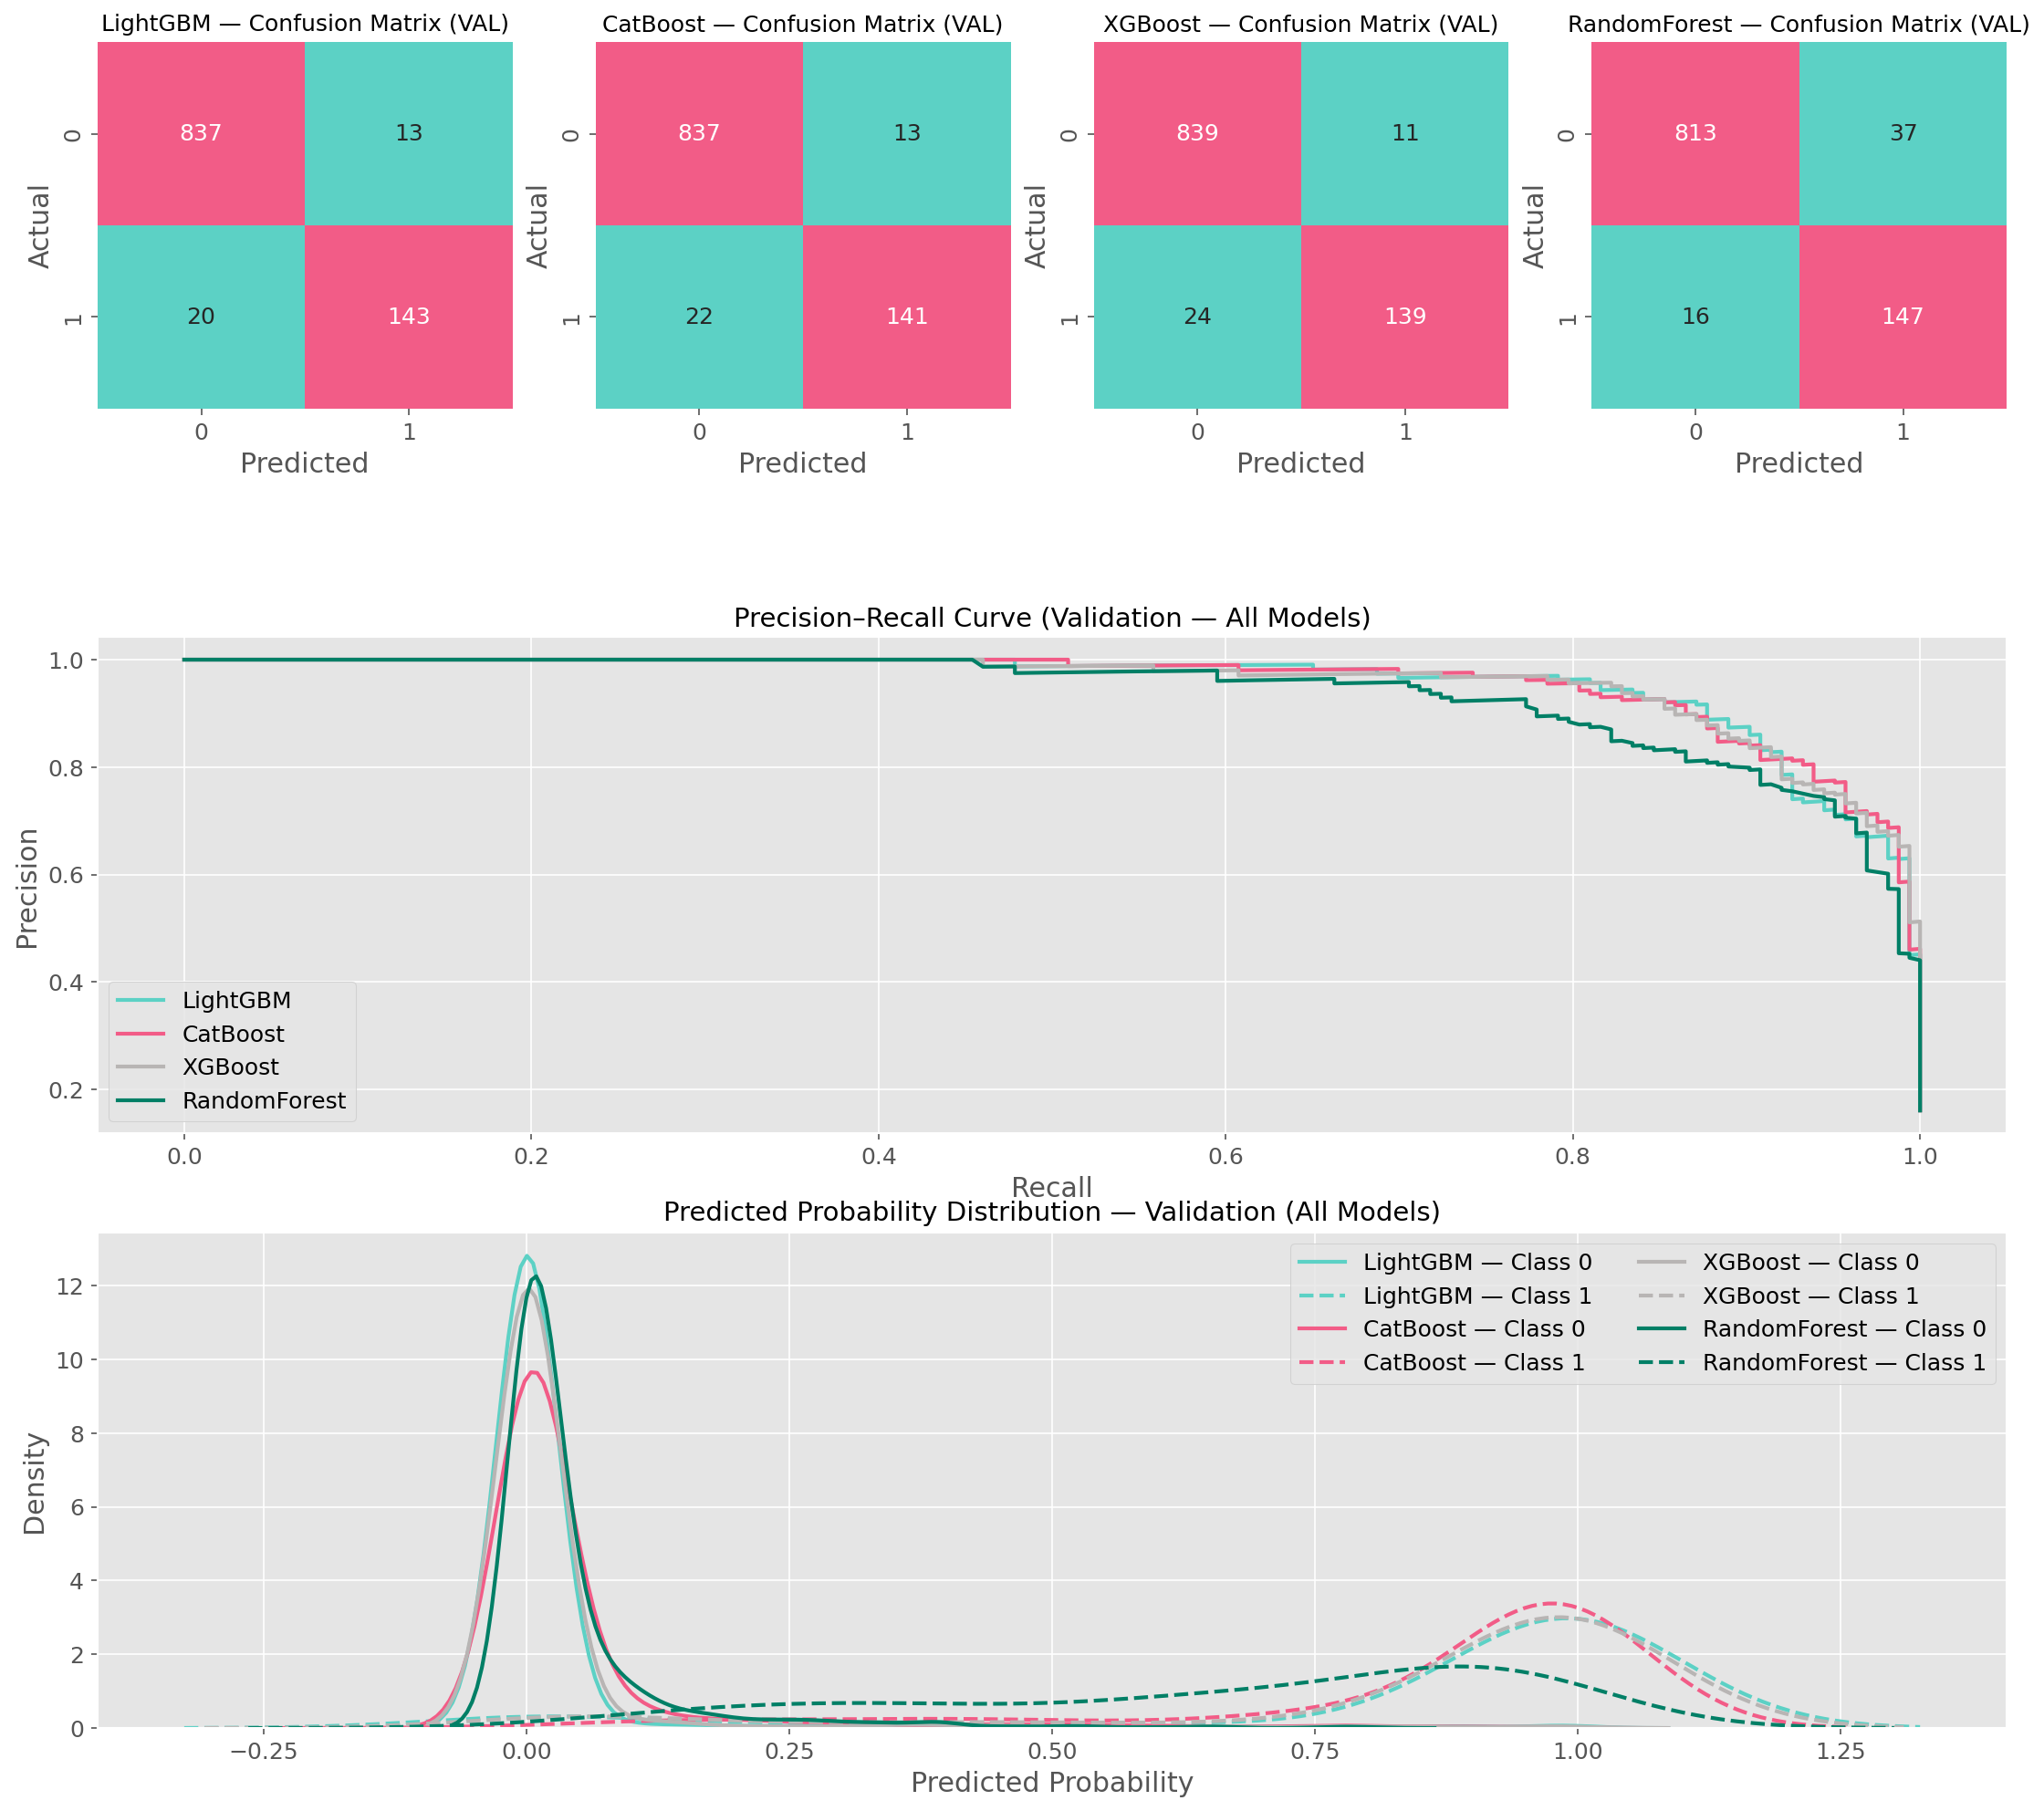

In [ ]:
# ---------- INITIAL MODEL SELECTION (BASELINE) ----------
# Purpose: Perform a fair comparison across candidate models to identify the most promising algorithms
# for subsequent hyperparameter tuning. Models are trained on TRAIN and evaluated exclusively on VAL.
# The TEST set remains untouched during this stage to prevent data leakage.

RANDOM_STATE = 42

# ---------- Class imbalance ratio (TRAIN ONLY) ----------
neg, pos = y_train.value_counts()
SCALE_POS_WEIGHT_BASELINE = neg / pos
print(f"Class imbalance ratio (neg/pos): {SCALE_POS_WEIGHT_BASELINE:.2f}")

# ---------- Helper: build a consistent pipeline for baseline ----------
def build_baseline_pipeline(model, model_name: str):

    """
    Builds a consistent baseline pipeline to ensure fair model comparison.

    Steps:
    - Apply feature engineering using the custom Preprocessor
    - Encode categorical variables using OrdinalEncoder after preprocessing
    - Train the specified model

    Although some algorithms support native categorical handling, a unified
    encoding strategy is used in this stage to isolate model performance differences.
    """

    # Map model -> preprocessor mode (dtype/format only; features are forced FULL for fairness)
    name_l = model_name.lower()
    if name_l.startswith("cat"):
        prep_mode = "catboost"
    elif name_l.startswith("light"):
        prep_mode = "lgbm"
    else:
        prep_mode = "xgb"  # XGBoost + RandomForest

    # FORCE FULL FEATURES for ALL models to keep selection fair
    preprocess = Preprocessor(mode=prep_mode, feature_set="full")

    def _cat_cols_from_df(df_):
        return df_.select_dtypes(include=["object", "category"]).columns.tolist()

    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    from sklearn.base import BaseEstimator, TransformerMixin

    class _EncodeCatsAfterPreprocess(BaseEstimator, TransformerMixin):
        def __init__(self, preprocessor, encoder):
            self.preprocessor = preprocessor
            self.encoder = encoder

        def fit(self, X, y=None):
            Xt = self.preprocessor.fit_transform(X, y)
            self.cat_cols_ = _cat_cols_from_df(Xt)
            if len(self.cat_cols_) > 0:
                self.encoder.fit(Xt[self.cat_cols_])
            return self

        def transform(self, X):
            Xt = self.preprocessor.transform(X)
            if len(getattr(self, "cat_cols_", [])) > 0:
                Xt = Xt.copy()
                Xt[self.cat_cols_] = self.encoder.transform(Xt[self.cat_cols_])
            return Xt

    return Pipeline(steps=[
        ("prep_enc", _EncodeCatsAfterPreprocess(preprocessor=preprocess, encoder=encoder)),
        ("model", model)
    ])

# ---------- Candidate models with baseline hyperparameters ----------

models = {
    "LightGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=SCALE_POS_WEIGHT_BASELINE,
        n_estimators=600,
        learning_rate=0.03,
        force_col_wise=True,
        verbosity=-1
    ),
    "CatBoost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        auto_class_weights="Balanced",
        iterations=600,
        learning_rate=0.03,
        verbose=0
    ),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        scale_pos_weight=SCALE_POS_WEIGHT_BASELINE,
        n_estimators=600,
        learning_rate=0.03,
        eval_metric="logloss"
    ),
    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=600,
        class_weight="balanced"
    )
}

# ---------- Containers for validation results ----------
results = {}
conf_matrices = {}
proba_data = {}
roc_data = {}
pr_data = {}

thresholds = np.linspace(0.01, 0.99, 99)

for name, model in models.items():
    print("\n===============================")
    print(f"Training {name} (baseline, TEST locked)...")
    print("===============================")

    pipe = build_baseline_pipeline(model, model_name=name)

    # Fit only on TRAIN
    pipe.fit(X_train, y_train)

    # Predict probabilities on VAL (for threshold optimization + evaluation)
    proba_val = pipe.predict_proba(X_val)[:, 1]

    # ---------- Threshold optimization (VAL) ----------
    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        preds_val_t = (proba_val >= t).astype(int)
        f1_t = f1_score(y_val, preds_val_t, pos_label=1)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_t = t

    print(f"Optimal threshold for {name}: {best_t:.3f}  |  F1_val(churn=1)={best_f1:.4f}")

# ---------- Generate validation predictions using optimized threshold ----------
    preds_val = (proba_val >= best_t).astype(int)

    # Save probability outputs for plots (VAL-based)
    proba_data[name] = proba_val

    # Save curves data (VAL-based)
    fpr, tpr, _ = roc_curve(y_val, proba_val)
    roc_data[name] = (fpr, tpr)
    pr_data[name] = precision_recall_curve(y_val, proba_val)

    # Metrics on VAL (TEST locked)
    results[name] = {
        "ROC-AUC": roc_auc_score(y_val, proba_val),
        "F1 Score": f1_score(y_val, preds_val),
        "F1 (churn=1)": f1_score(y_val, preds_val, pos_label=1),
        "Recall (churn=1)": recall_score(y_val, preds_val, pos_label=1),
        "Precision (churn=1)": precision_score(y_val, preds_val, pos_label=1),
        "Balanced Accuracy Score": balanced_accuracy_score(y_val, preds_val),
        "Threshold (from Val)": best_t
    }

    conf_matrices[name] = confusion_matrix(y_val, preds_val)

    tn, fp, fn, tp = conf_matrices[name].ravel()
    results[name].update({"FP": fp, "FN": fn, "TP": tp, "TN": tn})

    print(f"\nClassification Report — {name} (VAL):")
    print(classification_report(y_val, preds_val, digits=4))


# ---------- Validation Performance Summary ----------
results_df = pd.DataFrame(results).T.sort_values(by="F1 (churn=1)", ascending=False)
print("\n\n===== FINAL RESULTS (VALIDATION) =====")
print(results_df)


# ---------- VISUAL DASHBOARD (VAL) ----------
models_list = list(conf_matrices.keys())

fig = plt.figure(figsize=(18, 16))

# ---------- CONFUSION MATRICES ----------
for i, name in enumerate(models_list):
    ax = plt.subplot2grid((4, 4), (0, i))
    cm = conf_matrices[name]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
        cbar=False,
        norm=LogNorm(),
        ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix (VAL)", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# ---------- PRECISION–RECALL CURVES ----------
ax_pr = plt.subplot2grid((3, 4), (1, 0), colspan=4)

for i, name in enumerate(models_list):
    precision, recall, _ = pr_data[name]
    ax_pr.plot(
        recall,
        precision,
        label=name,
        linewidth=2,
        color=color_palette[i % len(color_palette)]
    )

ax_pr.set_title("Precision–Recall Curve (Validation — All Models)", fontsize=14)
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend()

# ---------- PROBABILITY DISTRIBUTION ----------
ax_prob = plt.subplot2grid((3, 4), (2, 0), colspan=4)

for i, name in enumerate(models_list):
    sns.kdeplot(
        proba_data[name][y_val == 0],
        label=f"{name} — Class 0",
        color=color_palette[i % len(color_palette)],
        linewidth=2,
        ax=ax_prob
    )
    sns.kdeplot(
        proba_data[name][y_val == 1],
        label=f"{name} — Class 1",
        color=color_palette[i % len(color_palette)],
        linestyle="--",
        linewidth=2,
        ax=ax_prob
    )

ax_prob.set_title("Predicted Probability Distribution — Validation (All Models)", fontsize=14)
ax_prob.set_xlabel("Predicted Probability")
ax_prob.set_ylabel("Density")
ax_prob.legend(ncol=2)

plt.tight_layout()
plt.show()

## Baseline Results and Model Shortlisting

The baseline comparison confirms that gradient boosting models (LightGBM, CatBoost, and XGBoost) deliver the best overall performance on the validation set, with strong discrimination (ROC-AUC ≈ 0.99) and a favorable precision–recall trade-off for the churn class.

### Key observations (Validation Set)

- **LightGBM achieved the best baseline performance for churn detection**, with the highest F1 score for the positive class (F1(churn=1)=0.8966), a strong recall (0.8773), and a high precision (0.9167). It also produced a low number of false positives (**FP=13**) while keeping false negatives reasonably controlled (**FN=20**).

- **CatBoost and XGBoost performed very similarly**, slightly below LightGBM in churn recall (0.8650 and 0.8528 respectively), and with comparable precision levels. Their confusion matrices show a similar error profile, with low false positive counts (FP=13 for CatBoost and FP=11 for XGBoost) but slightly higher false negatives than LightGBM.

- **RandomForest was excluded from hyperparameter tuning** despite its high recall (0.9018), because it produced a significantly higher number of false positives (**FP=37**) and the lowest precision for churn among all models (**Precision(churn=1)=0.7989**). This indicates a weaker probability ranking and poorer calibration for separating churn vs. non-churn cases, which is also reflected in the validation precision–recall curve where RandomForest consistently underperforms the boosting models.

### Rationale for excluding RandomForest

In churn prediction, recall is important, but operationally the model must also avoid generating excessive false positives, which can trigger unnecessary retention actions and increase business costs. Compared to the boosting models, RandomForest achieved only a modest recall advantage, but at the expense of a large increase in false positives and reduced churn precision. Therefore, the project proceeds with **LightGBM, CatBoost, and XGBoost** as final candidates for hyperparameter optimization, focusing on improving churn recall while preserving a practical false-positive rate.

## Hyperparameter Tuning Infrastructure (Common Infra)

To ensure a consistent and leakage-free tuning process across models, this project uses a shared training infrastructure that standardizes cross-validation, class imbalance handling, and pipeline construction.

The key design principle is to keep hyperparameter search **threshold-free** by optimizing **PR-AUC (Average Precision)** on train-only cross-validation. After tuning, the classification threshold is calibrated separately on the validation set, aligning the final decision rule with the business objective (prioritizing churn recall while controlling false positives).

The following block defines the common components used by LightGBM and CatBoost during tuning, including:
- Stratified cross-validation strategy
- Train-only class imbalance ratio
- Model-specific preprocessing pipelines with native categorical handling
- Helper functions for cross-validation scoring and threshold calibration


In [ ]:
# HYPERPARAMETER TUNING — COMMON INFRA
# ============================================================
# Purpose:
#   - Centralize shared components used during hyperparameter optimization
#   - Ensure train-only cross-validation (no leakage)
#   - Use threshold-free optimization (PR-AUC / Average Precision)
#   - Calibrate the decision threshold only AFTER tuning, using the validation set
#   - Build model-specific pipelines that preserve native categorical support where applicable
# ============================================================

RANDOM_STATE = 42

# ---------- CV strategy ----------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# ---------- Class imbalance ratio (TRAIN ONLY) ----------
neg, pos = y_train.value_counts()
SCALE_POS_WEIGHT = neg / pos
print(f"[TUNING INFRA] Class imbalance ratio (neg/pos): {SCALE_POS_WEIGHT:.2f}")

# ---------- Tuning metric (threshold-free): PR-AUC (Average Precision) ----------
SCORING_NAME = "PR-AUC"
SCORING = make_scorer(average_precision_score, needs_proba=True)

print(
    f"[TUNING INFRA] CV: {cv.get_n_splits()}-fold StratifiedKFold | "
    f"Scoring: {SCORING_NAME}"
)

# Model-specific pipeline builders (native categorical handling)
# ============================================================

def build_lgbm_pipeline(model, *, feature_set: str = "full", strict_schema: bool = True):

    """
    LightGBM pipeline:
    - Apply feature engineering using the project Preprocessor (mode="lgbm")
    - Preserve categorical dtype so LightGBM can handle categoricals natively
    """

    preprocess = Preprocessor(
        mode="lgbm",
        feature_set=feature_set,
        strict_schema=strict_schema,
        keep_raw_categoricals=True
    )
    return Pipeline(steps=[
        ("prep", preprocess),
        ("model", model),
    ])


def build_catboost_pipeline(model, *, feature_set: str = "full", strict_schema: bool = True):
    
    """
    CatBoost pipeline (native categorical handling):
    - Apply feature engineering using the project Preprocessor (mode="catboost")
    - Preserve categorical columns as object/category
    - Use a wrapper to automatically infer `cat_features` indices after preprocessing
    """

    preprocess = Preprocessor(
        mode="catboost",
        feature_set=feature_set,
        strict_schema=strict_schema,
        keep_raw_categoricals=True
    )

    class _CatBoostWithAutoCats(BaseEstimator, ClassifierMixin):

        """
        A sklearn-compatible wrapper that:
          - Fits the given CatBoostClassifier on the preprocessed DataFrame
          - Automatically detects categorical feature indices (object/category columns) on fit
          - Passes cat_features=... into CatBoost fit/predict_proba
        """

        def __init__(self, cat_model):
            self.cat_model = cat_model

        @staticmethod
        def _cat_feature_indices(df_):
            cat_cols = df_.select_dtypes(include=["object", "category"]).columns
            return [df_.columns.get_loc(c) for c in cat_cols]

        def fit(self, X, y):
            self.model_ = clone(self.cat_model)
            self.cat_features_ = self._cat_feature_indices(X)

            # CatBoost early stopping is handled via fit params; the objective code will pass eval_set if desired.
            self.model_.fit(X, y, cat_features=self.cat_features_)
            return self

        def predict(self, X):
            return self.model_.predict(X)

        def predict_proba(self, X):
            return self.model_.predict_proba(X)

    return Pipeline(steps=[
        ("prep", preprocess),
        ("model", _CatBoostWithAutoCats(model)),
    ])


# Early-stopping CV helper (TRAIN only, per fold)
# ============================================================

def cv_score_with_early_stopping(
    build_pipeline_fn,
    model,
    X,
    y,
    *,
    cv=cv,
    metric_name: str = "pr_auc",
    n_jobs: int = 1,
    verbose: bool = False,
):
    """
    Cross-validated scoring using TRAIN folds only, with early stopping support.

    Why not cross_val_score?
      - cross_val_score doesn't give per-fold eval_set hooks cleanly for early stopping.
      - We implement a manual CV loop and score on the fold's validation split.

    Parameters
    ----------
    build_pipeline_fn : callable
        build_lgbm_pipeline or build_catboost_pipeline
    model : estimator
        LGBMClassifier or CatBoostClassifier instance (already configured)
    X, y : training-only data
    metric_name : {"pr_auc"}
        currently implemented: pr_auc (Average Precision)
    """
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        pipe = build_pipeline_fn(model)

        # Fit with early-stopping hooks depending on model type
        # ----------------------------------------------------
        # LightGBM: fit(..., eval_set=[(X_val, y_val)], eval_metric=..., callbacks=[early_stopping])
        # CatBoost: fit(..., eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=...)
        #
        # We detect by attribute names / class name to avoid importing specific types here.
        model_step = pipe.named_steps["model"]

        if hasattr(model_step, "fit") and "lgbm" in model_step.__class__.__name__.lower():
            # (This branch usually won't trigger because for LGBM the model is the actual LGBMClassifier)
            pass

        # Pipeline fit: we need to pass fit params to the underlying estimator using step__param syntax
        fit_params = {}

        # LightGBM path (model is LGBMClassifier directly)
        if "lgbm" in model.__class__.__name__.lower():
            # Common early-stopping setup for LightGBM sklearn API
            # NOTE: requires lightgbm>=3.2 and supports callbacks
            from lightgbm import early_stopping, log_evaluation

            fit_params = {
                "model__eval_set": [(X_va, y_va)],
                "model__eval_metric": "average_precision",
                "model__callbacks": [
                    early_stopping(stopping_rounds=50, first_metric_only=True, verbose=verbose),
                    log_evaluation(period=0 if not verbose else 50),
                ],
            }

        # CatBoost path:
        # Early stopping is not applied here because the current wrapper does not forward eval_set parameters.
        # CatBoost training during tuning is handled directly inside its Optuna objective.
        elif "catboost" in model.__class__.__name__.lower():
            fit_params = {}

        pipe.fit(X_tr, y_tr, **fit_params)

        proba = pipe.predict_proba(X_va)[:, 1]

        if metric_name == "pr_auc":
            score = average_precision_score(y_va, proba)
        else:
            raise ValueError("metric_name not supported (use 'pr_auc').")

        scores.append(score)

        if verbose:
            print(f"[CV] fold={fold} score={score:.5f}")

    return float(np.mean(scores))

# Threshold calibration helper
# ============================================================

def find_best_threshold_on_val(
    y_true,
    proba,
    *,
    beta: float = 2.0,
    thresholds: np.ndarray | None = None
):
    """
    Finds a probability threshold that maximizes F-beta on a given validation set.
    Use this AFTER choosing the final tuned model, not inside CV.

    Returns
    -------
    best_threshold, best_fbeta
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    best_t = 0.5
    best_f = -1.0

    for t in thresholds:
        preds = (proba >= t).astype(int)
        f = fbeta_score(y_true, preds, beta=beta, pos_label=1)
        if f > best_f:
            best_f = f
            best_t = t

    return float(best_t), float(best_f)

# Notes:
# - Hyperparameter optimization uses PR-AUC on train-only CV.
# - Threshold calibration is performed after tuning on the validation set (beta can be adjusted to prioritize recall).

[TUNING INFRA] Class imbalance ratio (neg/pos): 5.22
[TUNING INFRA] CV: 3-fold StratifiedKFold | Scoring: PR-AUC


## Hyperparameter Tuning — LightGBM

After the baseline selection, LightGBM is tuned to maximize ranking quality under class imbalance, using **PR-AUC (Average Precision)** as the optimization metric.

To prevent leakage, all hyperparameter optimization is performed using **train-only stratified cross-validation**. The tuning process remains **threshold-free** during CV (PR-AUC does not depend on a classification threshold). After the best hyperparameters are found, the model is refit on the full training split and a **decision threshold is calibrated on the validation set**, aligning predictions with the business objective.

Because churn identification prioritizes capturing true churners, threshold calibration uses **F2-score (β=2)** to emphasize recall, while applying an operational constraint that caps the number of false positives (FP) on the validation set.

[I 2026-02-18 20:35:38,164] A new study created in memory with name: LightGBM_PR_AUC


[LGBM TUNING] Using COMMON INFRA cv: 3 folds
[LGBM TUNING] Using COMMON INFRA scoring: PR-AUC
[LGBM TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: 5.222


Best trial: 0. Best value: 0.966496:   2%|▏         | 1/50 [00:01<01:08,  1.39s/it]

[I 2026-02-18 20:35:39,554] Trial 0 finished with value: 0.9664957603728969 and parameters: {'spw_mult': 1.3231491363736883, 'n_estimators': 778, 'learning_rate': 0.03514716351416923, 'num_leaves': 32, 'max_depth': 8, 'min_child_samples': 96, 'min_split_gain': 0.07219436830753716, 'subsample': 0.7568124497053157, 'subsample_freq': 3, 'colsample_bytree': 0.6396538011495949, 'reg_alpha': 5.2648394892802616e-05, 'reg_lambda': 7.980123647599526e-06}. Best is trial 0 with value: 0.9664957603728969.


Best trial: 0. Best value: 0.966496:   4%|▍         | 2/50 [00:03<01:23,  1.74s/it]

...

[I 2026-02-18 20:37:32,093] Trial 47 finished with value: 0.9666329920898878 and parameters: {'spw_mult': 1.2013415672310614, 'n_estimators': 1730, 'learning_rate': 0.028655367854937434, 'num_leaves': 55, 'max_depth': 0, 'min_child_samples': 65, 'min_split_gain': 0.06816505062685269, 'subsample': 0.9079682844196753, 'subsample_freq': 3, 'colsample_bytree': 0.9819080182126121, 'reg_alpha': 0.00015081642266131696, 'reg_lambda': 0.030165241419918054}. Best is trial 18 with value: 0.967300066817199.


Best trial: 18. Best value: 0.9673:  98%|█████████▊| 49/50 [01:55<00:01,  1.96s/it]

[I 2026-02-18 20:37:33,238] Trial 48 finished with value: 0.9630902621246591 and parameters: {'spw_mult': 1.0249397980659607, 'n_estimators': 1282, 'learning_rate': 0.019836779335947064, 'num_leaves': 186, 'max_depth': 3, 'min_child_samples': 41, 'min_split_gain': 0.061098978675039634, 'subsample': 0.9948517554316321, 'subsample_freq': 4, 'colsample_bytree': 0.6562514014045753, 'reg_alpha': 3.626820494283612e-05, 'reg_lambda': 0.002917555943266366}. Best is trial 18 with value: 0.967300066817199.


Best trial: 18. Best value: 0.9673: 100%|██████████| 50/50 [01:56<00:00,  2.33s/it]


[I 2026-02-18 20:37:34,876] Trial 49 finished with value: 0.9667848740159111 and parameters: {'spw_mult': 1.2483592602073288, 'n_estimators': 1062, 'learning_rate': 0.016023080025823352, 'num_leaves': 130, 'max_depth': 5, 'min_child_samples': 71, 'min_split_gain': 0.09616667803592967, 'subsample': 0.8820967511497669, 'subsample_freq': 3, 'colsample_bytree': 0.8023811812394399, 'reg_alpha': 0.055663245407270925, 'reg_lambda': 5.912214653082104e-05}. Best is trial 18 with value: 0.967300066817199.

===== LIGHTGBM — OPTUNA BEST (CV TRAIN ONLY) =====
Best PR-AUC (CV mean - penalty): 0.96730
Best params:
{'spw_mult': 1.138122456006277, 'n_estimators': 2018, 'learning_rate': 0.017812324547947563, 'num_leaves': 168, 'max_depth': 6, 'min_child_samples': 52, 'min_split_gain': 0.09578840393415866, 'subsample': 0.9250981925785426, 'subsample_freq': 4, 'colsample_bytree': 0.9387911349836755, 'reg_alpha': 1.3143409042747192e-08, 'reg_lambda': 0.001929994734195262}

[LGBM] Selected threshold on VAL 

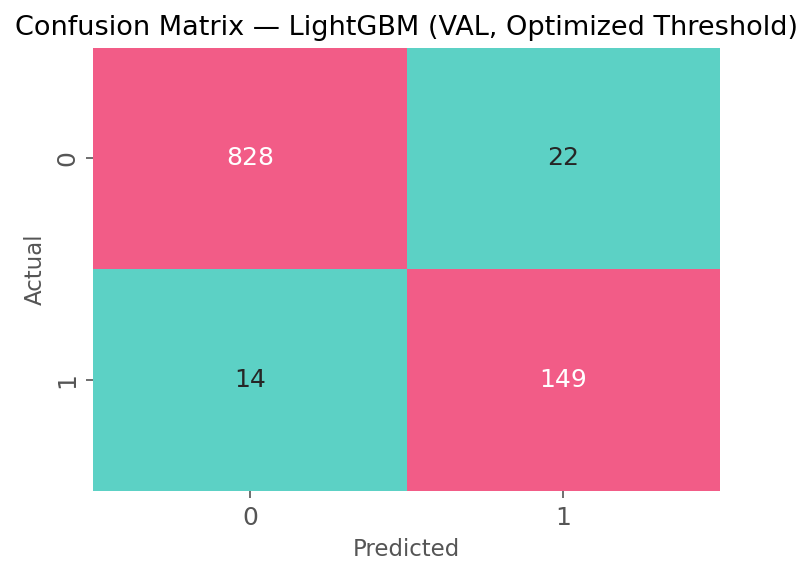


===== EXECUTIVE SUMMARY — LIGHTGBM (VAL) =====


,Value
Metric,
F2 Score (churn = 1) [VAL],0.9052
Recall (churn = 1) [VAL],0.9141
Precision (churn = 1) [VAL],0.8713
Balanced Accuracy [VAL],0.9441
ROC-AUC [VAL],0.9905
PR-AUC [VAL],0.9591
PR-AUC (CV Train),0.9673


In [ ]:
# HYPERPARAMETER TUNING — LIGHTGBM (Optuna, train-only CV)
# ============================================================
# Workflow:
#   1) Optimize PR-AUC via stratified CV using TRAIN only (leakage-free)
#   2) Refit the best model on the full TRAIN split
#   3) Calibrate the decision threshold on VAL using F-beta (beta=2) under constraints (FP cap)
# ============================================================

# Sanity check: ensure common tuning infrastructure is loaded
# -----------------------------
required_globals = ["cv", "SCALE_POS_WEIGHT", "SCORING_NAME", "build_lgbm_pipeline"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Common infra is not loaded. Missing: "
        + ", ".join(missing)
        + ". Run the COMMON INFRA cell first."
    )

RANDOM_STATE = 42
BETA_THRESHOLD = 2.0  # F2 emphasizes recall

print(f"[LGBM TUNING] Using COMMON INFRA cv: {cv.get_n_splits()} folds")
print(f"[LGBM TUNING] Using COMMON INFRA scoring: {SCORING_NAME}")
print(f"[LGBM TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: {float(SCALE_POS_WEIGHT):.3f}")


# CV scorer (TRAIN only) — NO early stopping
# ============================================================

def cv_pr_auc_lgbm(model, X, y, *, cv=cv, feature_set="full", strict_schema=True, verbose=False):

    """
    Manual train-only CV loop that scores PR-AUC (Average Precision) on each fold's holdout split.
    Uses the common LightGBM pipeline (native categorical handling).
    """

    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        pipe = build_lgbm_pipeline(model, feature_set=feature_set, strict_schema=strict_schema)
        pipe.fit(X_tr, y_tr)

        proba = pipe.predict_proba(X_va)[:, 1]
        score = average_precision_score(y_va, proba)
        scores.append(score)

        if verbose:
            print(f"[LGBM CV] fold={fold} {SCORING_NAME}={score:.5f}")

    return float(np.mean(scores)), float(np.std(scores))


# Threshold calibration on VAL (constraint-aware): prioritize fewer FN while controlling FP
# ============================================================

def select_threshold_constrained(
    y_true,
    proba,
    *,
    beta: float = 2.0,
    thresholds: np.ndarray | None = None,
    max_fp: int | None = None,
    min_precision: float | None = None,
    prefer: str = "min_fn_then_max_fbeta",
):
    """
    Choose a threshold under constraints to reduce FN without blowing up FP.

    prefer:
      - "min_fn_then_max_fbeta": minimize FN, then maximize F-beta, then maximize precision
      - "max_fbeta": maximize F-beta subject to constraints (fallback)
    """

    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 199)

    best = None

    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        prec = precision_score(y_true, preds, pos_label=1, zero_division=0)
        rec  = recall_score(y_true, preds, pos_label=1, zero_division=0)
        fbet = fbeta_score(y_true, preds, beta=beta, pos_label=1, zero_division=0)

        if max_fp is not None and fp > max_fp:
            continue
        if min_precision is not None and prec < min_precision:
            continue

        cand = {
            "threshold": float(t),
            "precision": float(prec),
            "recall": float(rec),
            "fbeta": float(fbet),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "tn": int(tn),
        }

        if best is None:
            best = cand
            continue

        if prefer == "min_fn_then_max_fbeta":
            key_best = (best["fn"], -best["fbeta"], -best["precision"])
            key_cand = (cand["fn"], -cand["fbeta"], -cand["precision"])
            if key_cand < key_best:
                best = cand

        elif prefer == "max_fbeta":
            key_best = (-best["fbeta"], best["fp"], best["fn"])
            key_cand = (-cand["fbeta"], cand["fp"], cand["fn"])
            if key_cand < key_best:
                best = cand
        else:
            raise ValueError("Invalid prefer option.")

    return best


# Optuna objective (CV on TRAIN only)
# ============================================================

def objective_lgb(trial):
    # Tune a small multiplier over the train-only imbalance ratio to control class cost sensitivity
    spw_mult = trial.suggest_float("spw_mult", 1.00, 1.40)
    scale_pos_weight = float(SCALE_POS_WEIGHT) * float(spw_mult)

    params = {
        "random_state": RANDOM_STATE,
        "objective": "binary",
        "boosting_type": "gbdt",
        "force_col_wise": True,
        "verbosity": -1,

        "scale_pos_weight": scale_pos_weight,

        "n_estimators": trial.suggest_int("n_estimators", 600, 2800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),

        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", -1, 12),

        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.12),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model = LGBMClassifier(**params)

    mean_pr_auc, std_pr_auc = cv_pr_auc_lgbm(
        model,
        X_train,
        y_train,
        cv=cv,
        feature_set="full",
        strict_schema=True,
        verbose=False
    )

    penalty = 0.10 * std_pr_auc
    return mean_pr_auc - penalty


# Run Optuna study
# ============================================================

study_lgb = optuna.create_study(direction="maximize", study_name="LightGBM_PR_AUC")
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print("\n===== LIGHTGBM — OPTUNA BEST (CV TRAIN ONLY) =====")
print(f"Best {SCORING_NAME} (CV mean - penalty): {study_lgb.best_value:.5f}")
print("Best params:")
print(study_lgb.best_params)


# Post-tuning evaluation:
# - Fit the best hyperparameters on TRAIN
# - Calibrate threshold on VAL (constraint-aware)
# - Report validation performance using the calibrated threshold
# ============================================================

best_params_lgb = study_lgb.best_params.copy()

spw_mult_best = float(best_params_lgb.pop("spw_mult", 1.00))
FINAL_SCALE_POS_WEIGHT = float(SCALE_POS_WEIGHT) * spw_mult_best

best_params_lgb.update({
    "random_state": RANDOM_STATE,
    "objective": "binary",
    "boosting_type": "gbdt",
    "force_col_wise": True,
    "verbosity": -1,
    "scale_pos_weight": FINAL_SCALE_POS_WEIGHT,
})

model_lgb_best = LGBMClassifier(**best_params_lgb)
pipe_lgb_best = build_lgbm_pipeline(model_lgb_best, feature_set="full", strict_schema=True)
pipe_lgb_best.fit(X_train, y_train)

proba_val_lgb = pipe_lgb_best.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 199)
FP_CAP = 24  # operational constraint: maximum tolerated false positives on VAL

sel = select_threshold_constrained(
    y_true=y_val,
    proba=proba_val_lgb,
    beta=BETA_THRESHOLD,
    thresholds=thresholds,
    max_fp=FP_CAP,
    min_precision=None,
    prefer="min_fn_then_max_fbeta",
)

if sel is None:
    # Fallback: if no threshold satisfies the FP cap, relax constraints using a minimum precision rule
    ref_t, _ = find_best_threshold_on_val(y_val, proba_val_lgb, beta=BETA_THRESHOLD, thresholds=thresholds)
    ref_preds = (proba_val_lgb >= ref_t).astype(int)
    ref_prec = precision_score(y_val, ref_preds, pos_label=1, zero_division=0)

    MIN_PRECISION = max(0.80, float(ref_prec))
    sel = select_threshold_constrained(
        y_true=y_val,
        proba=proba_val_lgb,
        beta=BETA_THRESHOLD,
        thresholds=thresholds,
        max_fp=None,
        min_precision=MIN_PRECISION,
        prefer="min_fn_then_max_fbeta",
    )

best_t_lgb = float(sel["threshold"])

print(
    f"\n[LGBM] Selected threshold on VAL (constraint-aware): {best_t_lgb:.3f} | "
    f"FP={sel['fp']} FN={sel['fn']} | Precision={sel['precision']:.4f} Recall={sel['recall']:.4f} | "
    f"F{int(BETA_THRESHOLD)}={sel['fbeta']:.4f} | scale_pos_weight={FINAL_SCALE_POS_WEIGHT:.3f}"
)

preds_val_lgb = (proba_val_lgb >= best_t_lgb).astype(int)

results_lgb = {
    "Threshold": best_t_lgb,
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_val, preds_val_lgb, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_val, proba_val_lgb),
    "PR-AUC (VAL)": average_precision_score(y_val, proba_val_lgb),
    "Recall (churn=1)": recall_score(y_val, preds_val_lgb, pos_label=1),
    "Precision (churn=1)": precision_score(y_val, preds_val_lgb, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_val, preds_val_lgb),
    "Confusion": confusion_matrix(y_val, preds_val_lgb),
    "Report": classification_report(y_val, preds_val_lgb, digits=4),
    "scale_pos_weight": FINAL_SCALE_POS_WEIGHT,
}

print("\n===== FINAL LIGHTGBM RESULTS (VAL, Optimized Threshold) =====")
print(results_lgb["Report"])
print(f"{SCORING_NAME} (CV train only, best trial): {study_lgb.best_value:.5f}")
print(f"PR-AUC (VAL): {results_lgb['PR-AUC (VAL)']:.4f}")
print(f"ROC-AUC (VAL): {results_lgb['ROC-AUC']:.4f}")
print(f"F{int(BETA_THRESHOLD)} (churn=1) (VAL): {results_lgb[f'F{int(BETA_THRESHOLD)} (churn=1)']:.4f}")
print(f"Recall (churn=1) (VAL): {results_lgb['Recall (churn=1)']:.4f}")
print(f"Precision (churn=1) (VAL): {results_lgb['Precision (churn=1)']:.4f}")
print(f"Best Threshold (VAL): {results_lgb['Threshold']:.3f}")
print(f"Final scale_pos_weight: {results_lgb['scale_pos_weight']:.3f}")

# Confusion matrix plot (VAL)
cm = results_lgb["Confusion"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
    norm=LogNorm(),
    cbar=False
)
plt.title("Confusion Matrix — LightGBM (VAL, Optimized Threshold)", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

# Executive summary (VAL)
executive_summary_lgb = pd.DataFrame({
    "Metric": [
        f"F{int(BETA_THRESHOLD)} Score (churn = 1) [VAL]",
        "Recall (churn = 1) [VAL]",
        "Precision (churn = 1) [VAL]",
        "Balanced Accuracy [VAL]",
        "ROC-AUC [VAL]",
        "PR-AUC [VAL]",
        f"{SCORING_NAME} (CV Train)"
    ],
    "Value": [
        results_lgb[f"F{int(BETA_THRESHOLD)} (churn=1)"],
        results_lgb["Recall (churn=1)"],
        results_lgb["Precision (churn=1)"],
        results_lgb["Balanced Accuracy"],
        results_lgb["ROC-AUC"],
        results_lgb["PR-AUC (VAL)"],
        study_lgb.best_value
    ]
}).set_index("Metric").round(4)

print("\n===== EXECUTIVE SUMMARY — LIGHTGBM (VAL) =====")
display(executive_summary_lgb)

## Hyperparameter Tuning — CatBoost

CatBoost is tuned as a strong baseline for tabular data with mixed feature types, especially when categorical variables carry predictive signal. In this project, CatBoost benefits from the preprocessing pipeline that preserves categorical columns and automatically passes categorical feature indices to the model.

As with the other models, hyperparameter optimization is performed using **train-only stratified cross-validation** and a **threshold-free objective (PR-AUC / Average Precision)** to evaluate ranking quality under class imbalance. The validation set is reserved for **threshold calibration**, where a decision cutoff is selected to maximize **F2-score (β=2)** while enforcing an operational **false-positive cap**.

To speed up the search, Optuna pruning is enabled and the training can optionally run on GPU when available.

[I 2026-02-18 19:32:15,620] A new study created in memory with name: CatBoost_PR_AUC


[CATBOOST TUNING] Using COMMON INFRA cv: 3 folds
[CATBOOST TUNING] Using COMMON INFRA scoring: PR-AUC
[CATBOOST TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: 5.222


Best trial: 0. Best value: 0.960083:   2%|▏         | 1/50 [01:47<1:27:52, 107.60s/it]

[I 2026-02-18 19:34:03,218] Trial 0 finished with value: 0.9600828497091147 and parameters: {'subsample': 0.8123620356542087, 'iterations': 1351, 'learning_rate': 0.06496385739540578, 'depth': 6, 'l2_leaf_reg': 0.03129892635009182, 'random_strength': 3.258263276654186e-08, 'min_data_in_leaf': 9}. Best is trial 0 with value: 0.9600828497091147.


Best trial: 1. Best value: 0.96468:   4%|▍         | 2/50 [02:27<53:59, 67.49s/it]    

...

[I 2026-02-18 20:30:15,794] Trial 47 finished with value: 0.9670436937179001 and parameters: {'subsample': 0.819626823656554, 'iterations': 771, 'learning_rate': 0.07445812581147217, 'depth': 8, 'l2_leaf_reg': 5.581530368781405, 'random_strength': 7.09515170634665e-05, 'min_data_in_leaf': 9}. Best is trial 28 with value: 0.9684121145815153.


Best trial: 28. Best value: 0.968412:  98%|█████████▊| 49/50 [58:55<01:09, 69.32s/it]

[I 2026-02-18 20:31:10,736] Trial 48 pruned. 


Best trial: 28. Best value: 0.968412: 100%|██████████| 50/50 [59:45<00:00, 71.71s/it]


[I 2026-02-18 20:32:01,116] Trial 49 pruned. 

===== CATBOOST — OPTUNA BEST (CV TRAIN ONLY) =====
Best PR-AUC (CV mean - penalty): 0.96841
Best params:
{'subsample': 0.8653768371210324, 'iterations': 520, 'learning_rate': 0.06454156823380956, 'depth': 7, 'l2_leaf_reg': 6.673058748977378, 'random_strength': 0.001695642968912918, 'min_data_in_leaf': 13}

[CATBOOST] FP-capped threshold on VAL: 0.337 | FP=24 FN=13 | Precision=0.8621 Recall=0.9202 | F2=0.9080

===== FINAL CATBOOST RESULTS (VAL, Optimized Threshold) =====
              precision    recall  f1-score   support

           0     0.9845    0.9718    0.9781       850
           1     0.8621    0.9202    0.8902       163

    accuracy                         0.9635      1013
   macro avg     0.9233    0.9460    0.9342      1013
weighted avg     0.9648    0.9635    0.9640      1013

PR-AUC (CV train only, best trial): 0.96841
PR-AUC (VAL): 0.9652
ROC-AUC (VAL): 0.9917
F2 (churn=1) (VAL): 0.9080
Recall (churn=1) (VAL): 0.9202
Precis

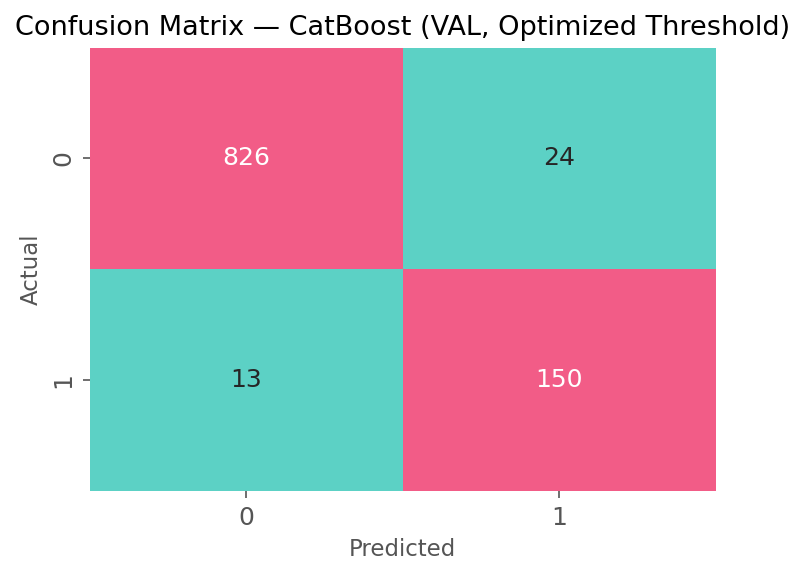


===== EXECUTIVE SUMMARY — CATBOOST (VAL) =====


,Value
Metric,
F2 Score (churn = 1) [VAL],0.9080
Recall (churn = 1) [VAL],0.9202
Precision (churn = 1) [VAL],0.8621
Balanced Accuracy [VAL],0.9460
ROC-AUC [VAL],0.9917
PR-AUC [VAL],0.9652
PR-AUC (CV Train),0.9684


In [ ]:
# HYPERPARAMETER TUNING — CATBOOST (Optuna, train-only CV)
# ============================================================
# Workflow:
#   1) Optimize PR-AUC via stratified CV using TRAIN only (leakage-free)
#   2) Refit the best hyperparameters on the full TRAIN split
#   3) Calibrate the decision threshold on VAL using F-beta (beta=2) with an FP cap
# Notes:
#   - Optuna pruning is enabled to reduce wasted trials
#   - Optional GPU acceleration can be used when available
# ============================================================

# Sanity check: ensure common tuning infrastructure is loaded
# -----------------------------

required_globals = ["cv", "SCALE_POS_WEIGHT", "SCORING_NAME", "build_catboost_pipeline"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Common infra is not loaded. Missing: "
        + ", ".join(missing)
        + ". Run the COMMON INFRA cell first."
    )

RANDOM_STATE = 42
BETA_THRESHOLD = 2.0  # F2 emphasizes recall

# ---------- Execution settings (GPU optional) ----------

USE_GPU = True
GPU_DEVICE = "0"
CPU_THREADS = -1  # -1 uses all available CPU threads (used when task_type="CPU")

print(f"[CATBOOST TUNING] Using COMMON INFRA cv: {cv.get_n_splits()} folds")
print(f"[CATBOOST TUNING] Using COMMON INFRA scoring: {SCORING_NAME}")
print(f"[CATBOOST TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: {float(SCALE_POS_WEIGHT):.3f}")


# CV scorer (TRAIN only) with Optuna pruning support
# ============================================================

def cv_pr_auc_catboost(
    model,
    X,
    y,
    *,
    cv=cv,
    feature_set="full",
    strict_schema=True,
    verbose=False,
    trial=None,  # Optuna trial for pruning
):

    """
    Manual train-only CV loop that scores PR-AUC (Average Precision) on each fold's holdout split.
    Uses the common CatBoost pipeline (native categorical handling with auto cat indices).
    Supports Optuna pruning by reporting intermediate fold means.
    """

    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        pipe = build_catboost_pipeline(model, feature_set=feature_set, strict_schema=strict_schema)
        pipe.fit(X_tr, y_tr)

        proba = pipe.predict_proba(X_va)[:, 1]
        score = average_precision_score(y_va, proba)
        scores.append(score)

        if verbose:
            print(f"[CATBOOST CV] fold={fold} {SCORING_NAME}={score:.5f}")

        if trial is not None:
            trial.report(float(np.mean(scores)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(scores)), float(np.std(scores))


# Threshold calibration on VAL (FP-capped): minimize FN first, then maximize F-beta, then precision
# ============================================================

def select_threshold_with_fp_cap(
    y_true,
    proba,
    *,
    beta: float = 2.0,
    thresholds: np.ndarray | None = None,
    fp_cap: int = 25,
):
    """
    Select a validation threshold under a hard operational constraint: FP <= fp_cap.
    Priority:
      1) minimize FN
      2) maximize F-beta
      3) maximize precision
    """

    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 199)

    best = None

    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        if fp > fp_cap:
            continue

        prec = precision_score(y_true, preds, pos_label=1, zero_division=0)
        rec  = recall_score(y_true, preds, pos_label=1, zero_division=0)
        fbet = fbeta_score(y_true, preds, beta=beta, pos_label=1, zero_division=0)

        cand = {
            "threshold": float(t),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "precision": float(prec),
            "recall": float(rec),
            "fbeta": float(fbet),
        }

        if best is None:
            best = cand
            continue

        key_best = (best["fn"], -best["fbeta"], -best["precision"])
        key_cand = (cand["fn"], -cand["fbeta"], -cand["precision"])
        if key_cand < key_best:
            best = cand

    return best


# Optuna objective (CV on TRAIN only) — faster + pruning
# ============================================================

def objective_cat(trial):
    # Class weights derived from the train-only imbalance ratio (leakage-free)
    class_weights = [1.0, float(SCALE_POS_WEIGHT)]

    # GPU constraints:
    # - Use Logloss as eval_metric for compatibility
    # - When subsampling on GPU, bootstrap_type must be "Bernoulli"

    params = {
        "random_seed": RANDOM_STATE,
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "verbose": 0,
        "allow_writing_files": False,
        "class_weights": class_weights,
        "thread_count": CPU_THREADS,
    }

    if USE_GPU:
        params.update({
            "task_type": "GPU",
            "devices": GPU_DEVICE,
            "bootstrap_type": "Bernoulli",
            "subsample": trial.suggest_float("subsample", 0.70, 1.0),
        })
    else:
        params.update({
            "task_type": "CPU",
            "bootstrap_type": "Bayesian",
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        })

    # Constrained search space to keep tuning efficient
    params.update({
        "iterations": trial.suggest_int("iterations", 400, 1400),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.10, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 15.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-9, 5.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 80),
    })

    model = CatBoostClassifier(**params)

    mean_pr_auc, std_pr_auc = cv_pr_auc_catboost(
        model,
        X_train,
        y_train,
        cv=cv,
        feature_set="full",
        strict_schema=True,
        verbose=False,
        trial=trial,
    )

    penalty = 0.10 * std_pr_auc
    return mean_pr_auc - penalty


# Run Optuna study (TPE sampler + median pruner)
# ============================================================

pruner = optuna.pruners.MedianPruner(n_warmup_steps=1)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study_cat = optuna.create_study(
    direction="maximize",
    study_name="CatBoost_PR_AUC",
    sampler=sampler,
    pruner=pruner
)

study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)

print("\n===== CATBOOST — OPTUNA BEST (CV TRAIN ONLY) =====")
print(f"Best {SCORING_NAME} (CV mean - penalty): {study_cat.best_value:.5f}")
print("Best params:")
print(study_cat.best_params)

# Post-tuning evaluation:
# - Fit the best hyperparameters on TRAIN
# - Calibrate threshold on VAL under an FP cap
# - Report validation performance using the calibrated threshold
# ============================================================

best_params_cat = study_cat.best_params.copy()
class_weights_final = [1.0, float(SCALE_POS_WEIGHT)]

final_params = {
    "random_seed": RANDOM_STATE,
    "loss_function": "Logloss",
    "eval_metric": "Logloss",
    "verbose": 0,
    "allow_writing_files": False,
    "class_weights": class_weights_final,
    "thread_count": CPU_THREADS,
}

# Apply tuned hyperparameters
final_params.update(best_params_cat)

# Re-apply platform-specific constraints (GPU vs CPU)
if USE_GPU:
    final_params.update({
        "task_type": "GPU",
        "devices": GPU_DEVICE,
        "bootstrap_type": "Bernoulli",
    })
else:
    final_params.update({
        "task_type": "CPU",
        "bootstrap_type": "Bayesian",
    })

model_cat_best = CatBoostClassifier(**final_params)

pipe_cat_best = build_catboost_pipeline(model_cat_best, feature_set="full", strict_schema=True)
pipe_cat_best.fit(X_train, y_train)

proba_val_cat = pipe_cat_best.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 199)

# If no threshold satisfies the initial FP cap, relax the constraint slightly.
sel = select_threshold_with_fp_cap(y_val, proba_val_cat, beta=BETA_THRESHOLD, thresholds=thresholds, fp_cap=25)
if sel is None:
    sel = select_threshold_with_fp_cap(y_val, proba_val_cat, beta=BETA_THRESHOLD, thresholds=thresholds, fp_cap=30)
if sel is None:
    raise ValueError("No threshold satisfies FP<=30. Consider relaxing cap or retraining/tuning.")

best_t_cat = float(sel["threshold"])
preds_val_cat = (proba_val_cat >= best_t_cat).astype(int)

print(
    f"\n[CATBOOST] FP-capped threshold on VAL: {best_t_cat:.3f} | "
    f"FP={sel['fp']} FN={sel['fn']} | Precision={sel['precision']:.4f} "
    f"Recall={sel['recall']:.4f} | F{int(BETA_THRESHOLD)}={sel['fbeta']:.4f}"
)

results_cat = {
    "Threshold": best_t_cat,
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_val, preds_val_cat, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_val, proba_val_cat),
    "PR-AUC (VAL)": average_precision_score(y_val, proba_val_cat),
    "Recall (churn=1)": recall_score(y_val, preds_val_cat, pos_label=1),
    "Precision (churn=1)": precision_score(y_val, preds_val_cat, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_val, preds_val_cat),
    "Confusion": confusion_matrix(y_val, preds_val_cat),
    "Report": classification_report(y_val, preds_val_cat, digits=4),
}

print("\n===== FINAL CATBOOST RESULTS (VAL, Optimized Threshold) =====")
print(results_cat["Report"])
print(f"{SCORING_NAME} (CV train only, best trial): {study_cat.best_value:.5f}")
print(f"PR-AUC (VAL): {results_cat['PR-AUC (VAL)']:.4f}")
print(f"ROC-AUC (VAL): {results_cat['ROC-AUC']:.4f}")
print(f"F{int(BETA_THRESHOLD)} (churn=1) (VAL): {results_cat[f'F{int(BETA_THRESHOLD)} (churn=1)']:.4f}")
print(f"Recall (churn=1) (VAL): {results_cat['Recall (churn=1)']:.4f}")
print(f"Precision (churn=1) (VAL): {results_cat['Precision (churn=1)']:.4f}")
print(f"Best Threshold (VAL): {results_cat['Threshold']:.3f}")

# ---------- CONFUSION MATRIX (VAL) ----------

cm = results_cat["Confusion"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
    norm=LogNorm(),
    cbar=False
)
plt.title("Confusion Matrix — CatBoost (VAL, Optimized Threshold)", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

# ---------- EXECUTIVE SUMMARY — MODEL PERFORMANCE (VAL) ----------

executive_summary_cat = pd.DataFrame({
    "Metric": [
        f"F{int(BETA_THRESHOLD)} Score (churn = 1) [VAL]",
        "Recall (churn = 1) [VAL]",
        "Precision (churn = 1) [VAL]",
        "Balanced Accuracy [VAL]",
        "ROC-AUC [VAL]",
        "PR-AUC [VAL]",
        f"{SCORING_NAME} (CV Train)"
    ],
    "Value": [
        results_cat[f"F{int(BETA_THRESHOLD)} (churn=1)"],
        results_cat["Recall (churn=1)"],
        results_cat["Precision (churn=1)"],
        results_cat["Balanced Accuracy"],
        results_cat["ROC-AUC"],
        results_cat["PR-AUC (VAL)"],
        study_cat.best_value
    ]
}).set_index("Metric").round(4)

print("\n===== EXECUTIVE SUMMARY — CATBOOST (VAL) =====")
display(executive_summary_cat)

## Hyperparameter Tuning — XGBoost

XGBoost is included as a high-performance gradient boosting baseline widely used in churn prediction and other tabular classification problems. Unlike LightGBM and CatBoost, this implementation requires categorical variables to be encoded, so the pipeline applies feature engineering first and then performs ordinal encoding to ensure a consistent and leakage-free transformation.

Hyperparameter tuning is performed using **train-only stratified cross-validation** and a **threshold-free objective (PR-AUC / Average Precision)**, which is well-suited for imbalanced classification. After selecting the best hyperparameters, the model is refit on the full training split and the **decision threshold is calibrated on the validation set** using **F2-score (β=2)** under a **false-positive constraint**, aligning model selection with operational requirements.

[I 2026-02-18 20:42:55,675] A new study created in memory with name: XGBoost_PR_AUC


[XGB TUNING] Using COMMON INFRA cv: 3 folds
[XGB TUNING] Using COMMON INFRA scoring: PR-AUC
[XGB TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: 5.222


Best trial: 0. Best value: 0.964153:   2%|▏         | 1/50 [00:03<03:12,  3.93s/it]

[I 2026-02-18 20:42:59,602] Trial 0 finished with value: 0.9641534237979894 and parameters: {'spw_mult': 1.2755094754130383, 'n_estimators': 1656, 'learning_rate': 0.04385996403094613, 'max_depth': 10, 'min_child_weight': 3.258554322896857, 'subsample': 0.7192505579930787, 'colsample_bytree': 0.6148589414725542, 'reg_alpha': 5.895826811292233e-07, 'reg_lambda': 9.78211100960705, 'gamma': 1.166225218598775}. Best is trial 0 with value: 0.9641534237979894.


Best trial: 0. Best value: 0.964153:   4%|▍         | 2/50 [00:05<02:05,  2.61s/it]

...

[I 2026-02-18 20:45:40,615] Trial 47 finished with value: 0.9638135742142917 and parameters: {'spw_mult': 1.248837711492278, 'n_estimators': 2048, 'learning_rate': 0.02145547976247297, 'max_depth': 4, 'min_child_weight': 1.156745991232264, 'subsample': 0.9880894623781572, 'colsample_bytree': 0.6809668782620728, 'reg_alpha': 2.8985099188972386e-09, 'reg_lambda': 1.193953317823811e-08, 'gamma': 3.1294272563673546}. Best is trial 22 with value: 0.966347446024537.


Best trial: 22. Best value: 0.966347:  98%|█████████▊| 49/50 [02:46<00:02,  2.75s/it]

[I 2026-02-18 20:45:41,763] Trial 48 finished with value: 0.9490008619943943 and parameters: {'spw_mult': 1.2143697997769538, 'n_estimators': 487, 'learning_rate': 0.015072114004957357, 'max_depth': 3, 'min_child_weight': 1.7477992668859, 'subsample': 0.8087461707678271, 'colsample_bytree': 0.7119241582851432, 'reg_alpha': 2.5231700318070946e-06, 'reg_lambda': 1.1146393457171425e-06, 'gamma': 4.153909803561067}. Best is trial 22 with value: 0.966347446024537.


Best trial: 22. Best value: 0.966347: 100%|██████████| 50/50 [02:50<00:00,  3.42s/it]


[I 2026-02-18 20:45:46,636] Trial 49 finished with value: 0.9631771342545339 and parameters: {'spw_mult': 1.2616732765550842, 'n_estimators': 1923, 'learning_rate': 0.011338062247419132, 'max_depth': 5, 'min_child_weight': 12.331959093073507, 'subsample': 0.6581565347988275, 'colsample_bytree': 0.783254781767644, 'reg_alpha': 0.3014116755183874, 'reg_lambda': 2.4543485893145754e-08, 'gamma': 2.529615068792088}. Best is trial 22 with value: 0.966347446024537.

===== XGBOOST — OPTUNA BEST (CV TRAIN ONLY) =====
Best PR-AUC (CV mean - penalty): 0.96635
Best params:
{'spw_mult': 1.316284512267516, 'n_estimators': 2171, 'learning_rate': 0.01410335187908191, 'max_depth': 4, 'min_child_weight': 1.8771707325361904, 'subsample': 0.7342806592881954, 'colsample_bytree': 0.7936267793893285, 'reg_alpha': 1.7069122574288386e-08, 'reg_lambda': 3.373313739287522e-08, 'gamma': 3.361865753214491}

[XGB] Selected threshold on VAL (constraint-aware): 0.455 | FP=22 FN=16 | Precision=0.8698 Recall=0.9018 | F

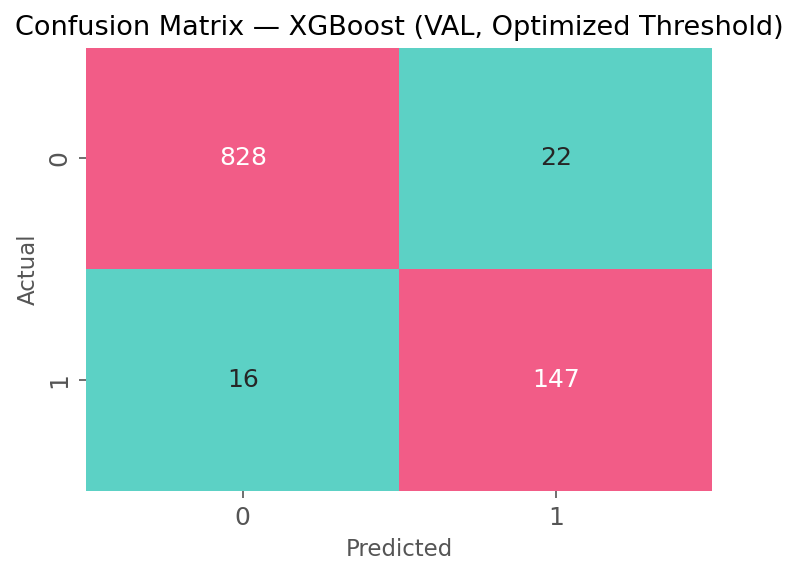


===== EXECUTIVE SUMMARY — XGBOOST (VAL) =====


,Value
Metric,
F2 Score (churn = 1) [VAL],0.8952
Recall (churn = 1) [VAL],0.9018
Precision (churn = 1) [VAL],0.8698
Balanced Accuracy [VAL],0.9380
ROC-AUC [VAL],0.9911
PR-AUC [VAL],0.9617
PR-AUC (CV Train),0.9663


In [ ]:
# HYPERPARAMETER TUNING — XGBOOST (Optuna, train-only CV)
# ============================================================
# Workflow:
#   1) Optimize PR-AUC via stratified CV using TRAIN only (leakage-free)
#   2) Refit the best hyperparameters on the full TRAIN split
#   3) Calibrate the decision threshold on VAL using F-beta (beta=2) with an FP cap
# Notes:
#   - XGBoost requires categorical encoding; we encode AFTER feature engineering
#   - Early stopping is intentionally disabled for stability and simpler comparison
# ============================================================

# Sanity check: ensure common tuning infrastructure is loaded
# ---------------------------------------------------------------

required_globals = ["cv", "SCALE_POS_WEIGHT", "SCORING_NAME"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Common infra is not loaded. Missing: "
        + ", ".join(missing)
        + ". Run the COMMON INFRA cell first."
    )

RANDOM_STATE = 42
BETA_THRESHOLD = 2.0  # F2 emphasizes recall

print(f"[XGB TUNING] Using COMMON INFRA cv: {cv.get_n_splits()} folds")
print(f"[XGB TUNING] Using COMMON INFRA scoring: {SCORING_NAME}")
print(f"[XGB TUNING] Using COMMON INFRA SCALE_POS_WEIGHT: {float(SCALE_POS_WEIGHT):.3f}")


# Pipeline builder: feature engineering first, then ordinal encoding for categorical columns
# ============================================================

class _EncodeCatsAfterPreprocess(BaseEstimator, TransformerMixin):

    """
    Applies feature engineering first (Preprocessor(mode="xgb")), then ordinal-encodes
    categorical columns so XGBoost can consume a fully numeric matrix.
    """

    def __init__(self, preprocessor, encoder=None):
        self.preprocessor = preprocessor
        self.encoder = encoder if encoder is not None else OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        )

    @staticmethod
    def _cat_cols_from_df(df_):
        return df_.select_dtypes(include=["object", "category"]).columns.tolist()

    def fit(self, X, y=None):
        Xt = self.preprocessor.fit_transform(X, y)
        self.cat_cols_ = self._cat_cols_from_df(Xt)

        if len(self.cat_cols_) > 0:
            self.encoder.fit(Xt[self.cat_cols_])

        return self

    def transform(self, X):
        Xt = self.preprocessor.transform(X)

        if len(getattr(self, "cat_cols_", [])) > 0:
            Xt = Xt.copy()
            Xt[self.cat_cols_] = self.encoder.transform(Xt[self.cat_cols_])

        return Xt


def build_xgb_pipeline(model, *, feature_set="lite", strict_schema=True):

    """
    XGB pipeline:
      - Preprocessor(mode="xgb"): feature engineering + categoricals as string
      - OrdinalEncoder: encode categoricals for XGBoost
      - XGBClassifier
    Note: feature_set="lite" is the default for XGBoost in this project to keep the feature space compact.
    """

    preprocess = Preprocessor(
        mode="xgb",
        feature_set=feature_set,         # "lite" by default for xgb
        strict_schema=strict_schema,
        keep_raw_categoricals=True
    )

    enc = _EncodeCatsAfterPreprocess(preprocessor=preprocess)

    return Pipeline(steps=[
        ("prep_enc", enc),
        ("model", model),
    ])


# CV scorer (TRAIN only) — NO early stopping
# ============================================================

def cv_pr_auc_xgb(model, X, y, *, cv=cv, feature_set="lite", strict_schema=True, verbose=False):
    scores = []

    """
    Manual train-only CV loop scoring PR-AUC (Average Precision) on each fold's holdout split.
    Early stopping is disabled to keep tuning behavior stable and comparable across trials.
    """

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        pipe = build_xgb_pipeline(model, feature_set=feature_set, strict_schema=strict_schema)
        pipe.fit(X_tr, y_tr)

        proba = pipe.predict_proba(X_va)[:, 1]
        score = average_precision_score(y_va, proba)
        scores.append(score)

        if verbose:
            print(f"[XGB CV] fold={fold} {SCORING_NAME}={score:.5f}")

    return float(np.mean(scores)), float(np.std(scores))


# Threshold calibration on VAL (constraint-aware): minimize FN, then maximize F-beta, then precision
# ============================================================

def select_threshold_constrained(
    y_true,
    proba,
    *,
    beta: float = 2.0,
    thresholds=None,
    max_fp: int | None = None,
    min_precision: float | None = None,
    prefer: str = "min_fn_then_max_fbeta",
):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 199)

    best = None

    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

        prec = precision_score(y_true, preds, pos_label=1, zero_division=0)
        rec  = recall_score(y_true, preds, pos_label=1, zero_division=0)
        fbet = fbeta_score(y_true, preds, beta=beta, pos_label=1, zero_division=0)

        if max_fp is not None and fp > max_fp:
            continue
        if min_precision is not None and prec < min_precision:
            continue

        cand = {
            "threshold": float(t),
            "precision": float(prec),
            "recall": float(rec),
            "fbeta": float(fbet),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "tn": int(tn),
        }

        if best is None:
            best = cand
            continue

        if prefer == "min_fn_then_max_fbeta":
            key_best = (best["fn"], -best["fbeta"], -best["precision"])
            key_cand = (cand["fn"], -cand["fbeta"], -cand["precision"])
            if key_cand < key_best:
                best = cand
        elif prefer == "max_fbeta":
            key_best = (-best["fbeta"], best["fp"], best["fn"])
            key_cand = (-cand["fbeta"], cand["fp"], cand["fn"])
            if key_cand < key_best:
                best = cand
        else:
            raise ValueError("Invalid prefer option.")

    return best


# Optuna objective (CV on TRAIN only)

# Notes:
#  - scale_pos_weight addresses class imbalance directly
#  - a small multiplier enables cost-sensitive tuning (recall-oriented trade-off)
# ============================================================

def objective_xgb(trial):
    spw_mult = trial.suggest_float("spw_mult", 1.20, 1.35)
    scale_pos_weight = float(SCALE_POS_WEIGHT) * float(spw_mult)

    params = {
        "random_state": RANDOM_STATE,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": -1,

        # imbalance
        "scale_pos_weight": scale_pos_weight,

        # speed/stability
        "tree_method": "hist",

        # search space
        "n_estimators": trial.suggest_int("n_estimators", 400, 2500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-9, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-9, 10.0, log=True),

        # split control
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }

    model = XGBClassifier(**params)

    mean_pr_auc, std_pr_auc = cv_pr_auc_xgb(
        model,
        X_train,
        y_train,
        cv=cv,
        feature_set="lite",
        strict_schema=True,
        verbose=False
    )

    penalty = 0.10 * std_pr_auc
    return mean_pr_auc - penalty


# Run Optuna study
# ============================================================
study_xgb = optuna.create_study(direction="maximize", study_name="XGBoost_PR_AUC")
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("\n===== XGBOOST — OPTUNA BEST (CV TRAIN ONLY) =====")
print(f"Best {SCORING_NAME} (CV mean - penalty): {study_xgb.best_value:.5f}")
print("Best params:")
print(study_xgb.best_params)


# POST-TUNING: fit on TRAIN, select threshold on VAL (constraints), report on VAL
# ============================================================
best_params_xgb = study_xgb.best_params.copy()

spw_mult_best = float(best_params_xgb.pop("spw_mult", 1.00))
FINAL_SCALE_POS_WEIGHT_XGB = float(SCALE_POS_WEIGHT) * spw_mult_best

best_params_xgb.update({
    "random_state": RANDOM_STATE,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_jobs": -1,
    "tree_method": "hist",
    "scale_pos_weight": FINAL_SCALE_POS_WEIGHT_XGB,
})

model_xgb_best = XGBClassifier(**best_params_xgb)
pipe_xgb_best = build_xgb_pipeline(model_xgb_best, feature_set="lite", strict_schema=True)
pipe_xgb_best.fit(X_train, y_train)

proba_val_xgb = pipe_xgb_best.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 199)

# Operational constraint: cap false positives during threshold calibration on VAL
FP_CAP = 25

sel = select_threshold_constrained(
    y_true=y_val,
    proba=proba_val_xgb,
    beta=BETA_THRESHOLD,
    thresholds=thresholds,
    max_fp=FP_CAP,
    min_precision=None,
    prefer="min_fn_then_max_fbeta",
)

if sel is None:
    # fallback: maximize F-beta without FP cap
    sel = select_threshold_constrained(
        y_true=y_val,
        proba=proba_val_xgb,
        beta=BETA_THRESHOLD,
        thresholds=thresholds,
        max_fp=None,
        min_precision=None,
        prefer="max_fbeta",
    )

best_t_xgb = float(sel["threshold"])
print(
    f"\n[XGB] Selected threshold on VAL (constraint-aware): {best_t_xgb:.3f} | "
    f"FP={sel['fp']} FN={sel['fn']} | Precision={sel['precision']:.4f} Recall={sel['recall']:.4f} | "
    f"F{int(BETA_THRESHOLD)}={sel['fbeta']:.4f} | scale_pos_weight={FINAL_SCALE_POS_WEIGHT_XGB:.3f}"
)

# ---------- Final VAL predictions using chosen threshold ----------
preds_val_xgb = (proba_val_xgb >= best_t_xgb).astype(int)

# ---------- Metrics on VAL ----------
results_xgb = {
    "Threshold": float(best_t_xgb),
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_val, preds_val_xgb, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_val, proba_val_xgb),
    "PR-AUC (VAL)": average_precision_score(y_val, proba_val_xgb),
    "Recall (churn=1)": recall_score(y_val, preds_val_xgb, pos_label=1),
    "Precision (churn=1)": precision_score(y_val, preds_val_xgb, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_val, preds_val_xgb),
    "Confusion": confusion_matrix(y_val, preds_val_xgb),
    "Report": classification_report(y_val, preds_val_xgb, digits=4),
    "scale_pos_weight": float(FINAL_SCALE_POS_WEIGHT_XGB),
}

# FINAL XGBOOST RESULTS (VAL, Calibrated Threshold)
# ============================================================

print("\n===== FINAL XGBOOST RESULTS (VAL, Optimized Threshold) =====")
print(results_xgb["Report"])
print(f"{SCORING_NAME} (CV train only, best trial): {study_xgb.best_value:.5f}")
print(f"PR-AUC (VAL): {results_xgb['PR-AUC (VAL)']:.4f}")
print(f"ROC-AUC (VAL): {results_xgb['ROC-AUC']:.4f}")
print(f"F{int(BETA_THRESHOLD)} (churn=1) (VAL): {results_xgb[f'F{int(BETA_THRESHOLD)} (churn=1)']:.4f}")
print(f"Recall (churn=1) (VAL): {results_xgb['Recall (churn=1)']:.4f}")
print(f"Precision (churn=1) (VAL): {results_xgb['Precision (churn=1)']:.4f}")
print(f"Best Threshold (VAL): {results_xgb['Threshold']:.3f}")
print(f"scale_pos_weight: {results_xgb['scale_pos_weight']:.3f}")

# ---------- CONFUSION MATRIX (VAL) ----------

cm = results_xgb["Confusion"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
    norm=LogNorm(),
    cbar=False
)
plt.title("Confusion Matrix — XGBoost (VAL, Optimized Threshold)", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

# ---------- EXECUTIVE SUMMARY — MODEL PERFORMANCE (VAL) ----------

executive_summary_xgb = pd.DataFrame({
    "Metric": [
        f"F{int(BETA_THRESHOLD)} Score (churn = 1) [VAL]",
        "Recall (churn = 1) [VAL]",
        "Precision (churn = 1) [VAL]",
        "Balanced Accuracy [VAL]",
        "ROC-AUC [VAL]",
        "PR-AUC [VAL]",
        f"{SCORING_NAME} (CV Train)"
    ],
    "Value": [
        results_xgb[f"F{int(BETA_THRESHOLD)} (churn=1)"],
        results_xgb["Recall (churn=1)"],
        results_xgb["Precision (churn=1)"],
        results_xgb["Balanced Accuracy"],
        results_xgb["ROC-AUC"],
        results_xgb["PR-AUC (VAL)"],
        study_xgb.best_value
    ]
}).set_index("Metric").round(4)

print("\n===== EXECUTIVE SUMMARY — XGBOOST (VAL) =====")
display(executive_summary_xgb)


===== FINAL MODEL COMPARISON (VALIDATION SET) =====


,Model,Threshold,F1 (churn=1),Precision (churn=1),Recall (churn=1),ROC-AUC,Balanced Accuracy
0,LightGBM,0.237677,0.892216,0.871345,0.914110,0.990466,0.944114
1,CatBoost,0.336667,0.890208,0.862069,0.920245,0.991721,0.946005
2,XGBoost,0.455455,0.885542,0.869822,0.901840,0.991130,0.937979


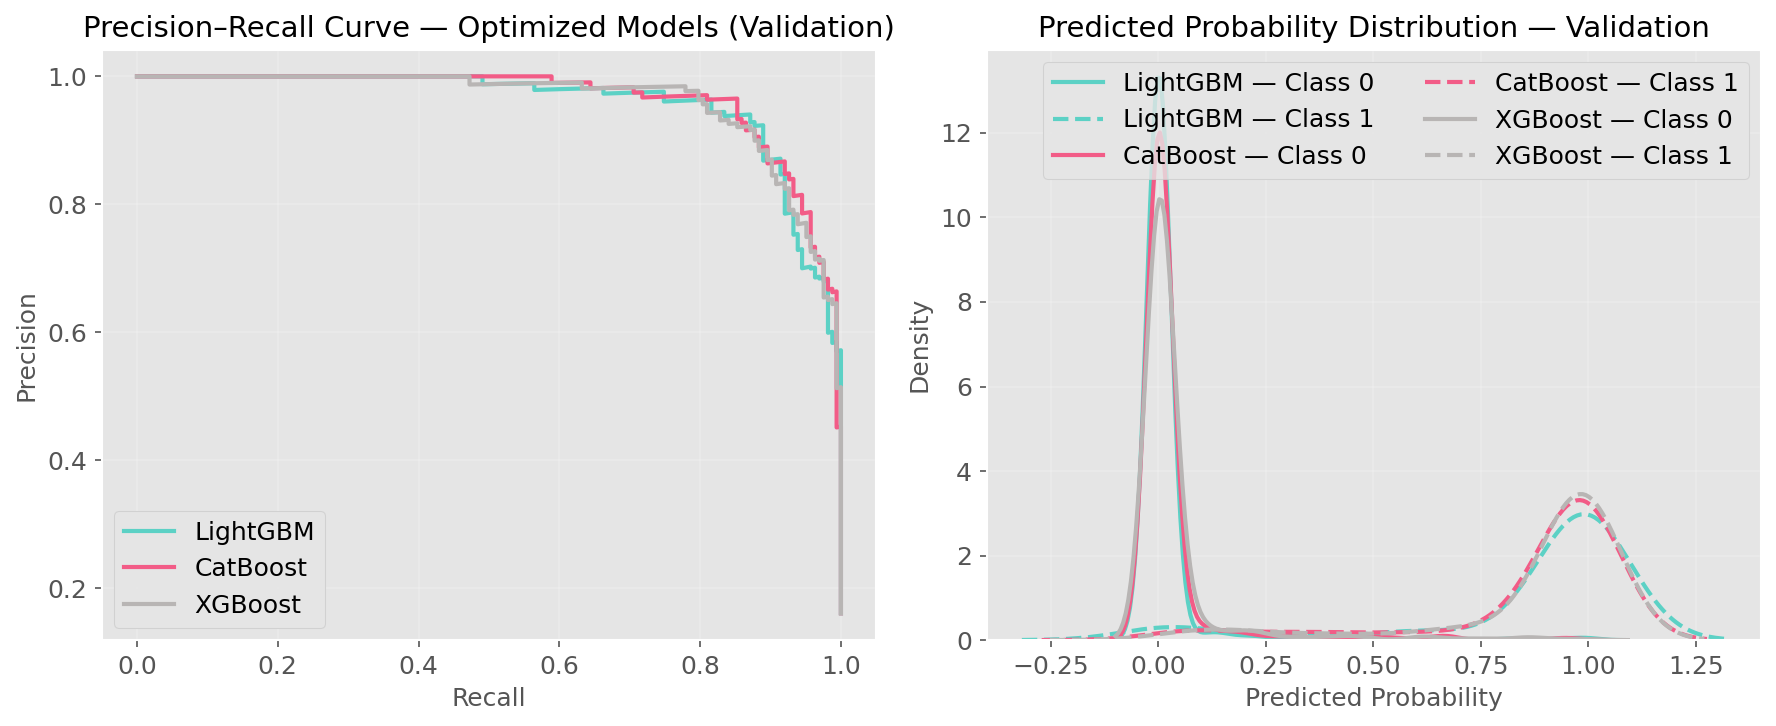

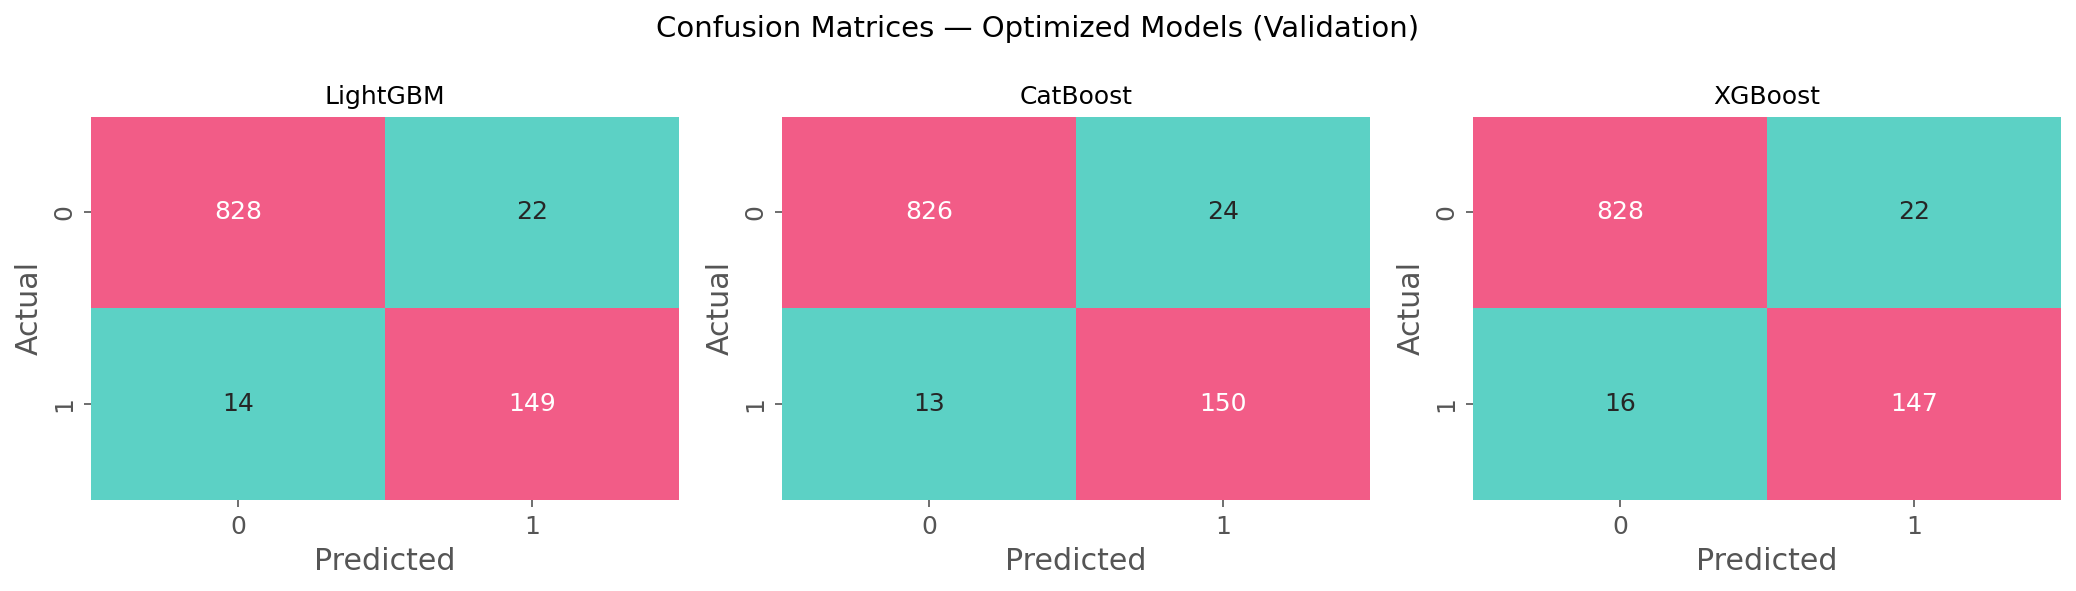

In [ ]:
# FINAL MODEL COMPARISON (VALIDATION) — OPTIMIZED LIGHTGBM vs CATBOOST vs XGBOOST
# ============================================================
# All models:
#   - Tuned with CV on TRAIN only (PR-AUC / Average Precision)
#   - Threshold calibrated on VAL (business-oriented operating point)
# Here:
#   - We evaluate the tuned pipelines on VAL using the frozen thresholds
#   - We visualize PR curves, probability separation, and confusion matrices
# ============================================================

# ---------- Standardized evaluation (single function for all models) ----------
def evaluate_pipeline(name, pipeline, X, y, threshold):

    # Note: PR curve is computed from probabilities (threshold-free).
    # Metrics below use the provided threshold (operating point).

    proba = pipeline.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)

    precision, recall, _ = precision_recall_curve(y, proba)

    return {
        "Model": name,
        "Threshold": float(threshold),
        "F1 (churn=1)": f1_score(y, preds, pos_label=1),
        "Precision (churn=1)": precision_score(y, preds, pos_label=1),
        "Recall (churn=1)": recall_score(y, preds, pos_label=1),
        "ROC-AUC": roc_auc_score(y, proba),
        "Balanced Accuracy": balanced_accuracy_score(y, preds),
        "Confusion": confusion_matrix(y, preds),
        "Proba": proba,
        "PR_curve": (precision, recall),
    }


# ---------- Evaluate tuned pipelines on VAL (frozen thresholds) ----------

results_optimized = []

results_optimized.append(
    evaluate_pipeline("LightGBM", pipe_lgb_best, X_val, y_val, best_t_lgb)
)

results_optimized.append(
    evaluate_pipeline("CatBoost", pipe_cat_best, X_val, y_val, best_t_cat)
)

results_optimized.append(
    evaluate_pipeline("XGBoost", pipe_xgb_best, X_val, y_val, best_t_xgb)
)

results_optimized_df = (
    pd.DataFrame(results_optimized)
      .drop(columns=["Confusion", "Proba", "PR_curve"])
      .sort_values(by="F1 (churn=1)", ascending=False)
)

print("\n===== FINAL MODEL COMPARISON (VALIDATION SET) =====")
display(results_optimized_df)


# ---------- Consistent color mapping across plots ----------

model_colors = {
    "LightGBM": color_palette[0],
    "CatBoost": color_palette[1],
    "XGBoost":  color_palette[2],
}

# ---------- Diagnostics on VAL: PR curve + probability separation ----------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR curve
for r in results_optimized:
    precision, recall = r["PR_curve"]
    axes[0].plot(
        recall,
        precision,
        linewidth=2,
        label=r["Model"],
        color=model_colors.get(r["Model"], color_palette[0])
    )

axes[0].set_title("Precision–Recall Curve — Optimized Models (Validation)", fontsize=14)
axes[0].set_xlabel("Recall", fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.2)

# Probability distribution
for r in results_optimized:
    c = model_colors.get(r["Model"], color_palette[0])
    sns.kdeplot(
        r["Proba"][y_val == 0],
        label=f"{r['Model']} — Class 0",
        linewidth=2,
        color=c,
        ax=axes[1]
    )
    sns.kdeplot(
        r["Proba"][y_val == 1],
        label=f"{r['Model']} — Class 1",
        linewidth=2,
        linestyle="--",
        color=c,
        ax=axes[1]
    )

axes[1].set_title("Predicted Probability Distribution — Validation", fontsize=14)
axes[1].set_xlabel("Predicted Probability", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ---------- Operating point impact: confusion matrices (VAL) ----------

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, r in zip(axes, results_optimized):
    sns.heatmap(
        r["Confusion"],
        annot=True,
        fmt="d",
        cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
        norm=LogNorm(),
        cbar=False,
        ax=ax
    )
    ax.set_title(r["Model"], fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Optimized Models (Validation)", fontsize=14)
plt.tight_layout()
plt.show()

## Comparative Analysis of Optimized Models

After hyperparameter optimization, the three gradient boosting models — LightGBM, CatBoost, and XGBoost — demonstrated very strong and closely aligned performance on the validation set. This indicates that the engineered feature space provides a high-quality signal for churn prediction, allowing different boosting frameworks to learn similarly effective decision boundaries.

Although overall performance is comparable, each model exhibits distinct strengths and trade-offs that are important to consider when selecting the final production model.

### LightGBM

LightGBM achieved the **highest F1 score for the churn class**, reflecting a strong balance between precision and recall. Its recall performance is high while maintaining solid precision, indicating that the model can detect a large portion of churn cases without excessively increasing false positives.

Another advantage of LightGBM is its computational efficiency and scalability. The histogram-based tree growth strategy enables faster training and lower memory usage, which is particularly valuable in production environments or when retraining models periodically.

From an operational perspective, LightGBM provides a stable decision boundary and well-separated probability distributions, suggesting reliable probability calibration and consistent classification behavior.

### CatBoost

CatBoost achieved the **highest recall among the three models**, meaning it is slightly more aggressive in identifying churn cases. This can be beneficial in scenarios where missing a potential churn customer is significantly more costly than contacting a non-churn customer.

Additionally, CatBoost demonstrated the highest ROC-AUC, indicating strong ranking ability and excellent discrimination between classes.

However, this increased sensitivity comes with a small reduction in precision, meaning a slightly higher number of false positives compared to LightGBM. CatBoost models also tend to be computationally heavier, especially when GPU acceleration is not available, which may impact deployment efficiency.

### XGBoost

XGBoost delivered very competitive performance with strong ROC-AUC and solid precision, demonstrating its robustness as a gradient boosting framework. Its probability separation is consistent, and the model shows stable behavior across metrics.

Nevertheless, XGBoost produced slightly lower recall and F1 score compared to LightGBM and CatBoost, indicating that it misses marginally more churn cases under the chosen operating point. While still a high-performing model, it does not offer a clear advantage over the alternatives in this context.

### Overall Interpretation

The comparison shows that all three models are capable of capturing the underlying churn patterns effectively, with only marginal differences in predictive performance. The choice between them ultimately depends on the preferred trade-off between recall, precision, computational efficiency, and operational simplicity.

In practical terms, LightGBM and CatBoost stand out as the strongest candidates due to their superior balance of metrics and consistent probability behavior, while XGBoost remains a solid but slightly less competitive option for this specific dataset.

## Final Model Selection and Validation Checkpoint

Following hyperparameter optimization and comparative evaluation, **LightGBM** was selected as the final modeling approach for this project.

Although all three gradient boosting models demonstrated strong predictive performance, LightGBM provided the best overall balance between recall, precision, stability, and operational simplicity. Its ability to maintain high recall for the churn class while controlling false positives aligned well with the project’s objective of minimizing missed churn cases without generating excessive intervention costs.

Additionally, LightGBM showed consistent behavior across cross-validation and validation metrics, indicating strong generalization capability and reduced risk of overfitting compared to alternative models.

At this stage, the selected hyperparameters and decision threshold are **frozen based on validation performance**. This step establishes a stable reference configuration before moving to final testing, ensuring that no further adjustments are made using unseen data.

The following section applies the frozen LightGBM configuration to the validation set to confirm performance consistency before proceeding to the final evaluation stage.

In [ ]:
# ============================================================
# LIGHTGBM (Frozen) — Validation Checkpoint
# ============================================================
# Goal:
#   - Fix the selected hyperparameters and decision threshold
#   - Evaluate on the validation set without any re-optimization
#   - Establish a stable operating point before touching the test set
# ============================================================

# Safety check: ensure the shared pipeline builder is available
# -----------------------------
required_globals = ["build_lgbm_pipeline", "SCORING_NAME"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Common infra is not loaded. Missing: "
        + ", ".join(missing)
        + ". Run the COMMON INFRA cell first."
    )

RANDOM_STATE = 42
BETA_THRESHOLD = 2.0  # F2 emphasizes recall

# Frozen hyperparameters selected during Optuna tuning (TRAIN-only CV)
# ============================================================
BEST_PARAMS_LGB_FROZEN = {
    "spw_mult": 1.3802998654302598,
    "n_estimators": 2272,
    "learning_rate": 0.013202700260711138,
    "num_leaves": 104,
    "max_depth": 5,
    "min_child_samples": 22,
    "min_split_gain": 0.11140570440980045,
    "subsample": 0.8992819819075484,
    "subsample_freq": 3,
    "colsample_bytree": 0.6761596069968356,
    "reg_alpha": 6.055129310001375e-07,
    "reg_lambda": 9.326994358848609e-08,
}

# Frozen decision threshold calibrated on VAL (constraint-aware operating point)
BEST_THRESHOLD_LGB_FROZEN = 0.272

# Final class-weighting factor used by LightGBM (derived from TRAIN imbalance and tuned multiplier)
FINAL_SCALE_POS_WEIGHT_LGB_FROZEN = 7.208

# Optional: keep the “best trial” value for consistent printing (manual constant)
BEST_CV_VALUE_LGB_FROZEN = 0.96777  # "Best PR-AUC (CV mean - penalty)" from your output

# Build pipeline with native categorical handling (LightGBM + engineered features)
# ============================================================

best_params_lgb = BEST_PARAMS_LGB_FROZEN.copy()
best_params_lgb.pop("spw_mult", None)

best_params_lgb.update({
    "random_state": RANDOM_STATE,
    "objective": "binary",
    "boosting_type": "gbdt",
    "force_col_wise": True,
    "verbosity": -1,
    "scale_pos_weight": float(FINAL_SCALE_POS_WEIGHT_LGB_FROZEN),
})

model_lgb_frozen = LGBMClassifier(**best_params_lgb)
pipe_lgb_frozen = build_lgbm_pipeline(model_lgb_frozen, feature_set="full", strict_schema=True)

# Train on TRAIN only; keep VAL strictly for calibration/evaluation
pipe_lgb_frozen.fit(X_train, y_train)

# Predict probabilities on VAL
proba_val_lgb = pipe_lgb_frozen.predict_proba(X_val)[:, 1]

# Apply frozen threshold (no re-optimization on VAL)
best_t_lgb = float(BEST_THRESHOLD_LGB_FROZEN)
preds_val_lgb = (proba_val_lgb >= best_t_lgb).astype(int)

# Validation metrics at the frozen operating point
# ============================================================

results_lgb = {
    "Threshold": best_t_lgb,
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_val, preds_val_lgb, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_val, proba_val_lgb),
    "PR-AUC (VAL)": average_precision_score(y_val, proba_val_lgb),
    "Recall (churn=1)": recall_score(y_val, preds_val_lgb, pos_label=1),
    "Precision (churn=1)": precision_score(y_val, preds_val_lgb, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_val, preds_val_lgb),
    "Confusion": confusion_matrix(y_val, preds_val_lgb),
    "Report": classification_report(y_val, preds_val_lgb, digits=4),
    "scale_pos_weight": float(FINAL_SCALE_POS_WEIGHT_LGB_FROZEN),
}

## Final Evaluation on the Test Set

After confirming stable performance on the validation set using the frozen configuration, the final step is to evaluate the model on the **held-out test set**.

The test set represents completely unseen data and is used exclusively to assess the model’s true generalization capability. No hyperparameter tuning, threshold optimization, or model adjustments are performed at this stage to preserve the integrity of the evaluation process.

The previously selected decision threshold — determined using the validation set — is applied unchanged, ensuring that performance metrics reflect a realistic production scenario where model parameters remain fixed after deployment.

This evaluation provides the most reliable estimate of how the model is expected to perform in real-world conditions, particularly in its ability to correctly identify churn cases while maintaining controlled false positive rates.


===== FINAL LIGHTGBM RESULTS (TEST, Frozen Threshold) =====
              precision    recall  f1-score   support

           0     0.9904    0.9730    0.9816       851
           1     0.8701    0.9506    0.9086       162

    accuracy                         0.9694      1013
   macro avg     0.9302    0.9618    0.9451      1013
weighted avg     0.9712    0.9694    0.9699      1013

PR-AUC (TEST): 0.9735
ROC-AUC (TEST): 0.9930
F2 (churn=1) (TEST): 0.9333
Recall (churn=1) (TEST): 0.9506
Precision (churn=1) (TEST): 0.8701
Frozen Threshold (from VAL): 0.272


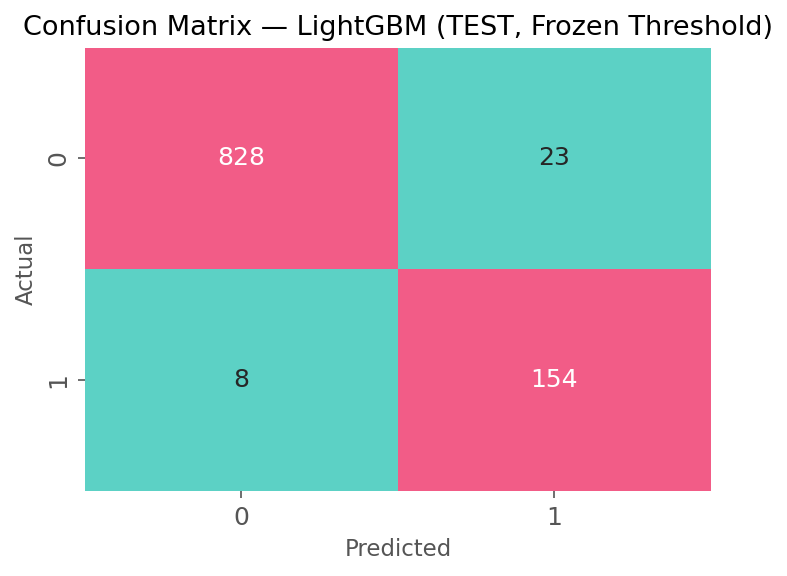


===== EXECUTIVE SUMMARY — LIGHTGBM (TEST) =====


,Value
Metric,
F2 Score (churn = 1) [TEST],0.9333
Recall (churn = 1) [TEST],0.9506
Precision (churn = 1) [TEST],0.8701
Balanced Accuracy [TEST],0.9618
ROC-AUC [TEST],0.9930
PR-AUC [TEST],0.9735
Frozen Threshold (from VAL),0.2720


In [ ]:
# LIGHTGBM (Frozen) — Final Evaluation on TEST
# # ============================================================


# Purpose:
#   - Evaluate the finalized LightGBM model on completely unseen data
#   - Use the threshold selected on the validation set without any re-optimization
#   - Provide an unbiased estimate of real-world performance

best_t_lgb = float(BEST_THRESHOLD_LGB_FROZEN)

# ---------- Generate probability predictions on TEST ----------
proba_test_lgb = pipe_lgb_frozen.predict_proba(X_test)[:, 1]
preds_test_lgb = (proba_test_lgb >= best_t_lgb).astype(int)

# Test metrics at the frozen threshold
results_lgb_test = {
    "Threshold": best_t_lgb,
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_test, preds_test_lgb, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test, proba_test_lgb),
    "PR-AUC (TEST)": average_precision_score(y_test, proba_test_lgb),
    "Recall (churn=1)": recall_score(y_test, preds_test_lgb, pos_label=1),
    "Precision (churn=1)": precision_score(y_test, preds_test_lgb, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_test, preds_test_lgb),
    "Confusion": confusion_matrix(y_test, preds_test_lgb),
    "Report": classification_report(y_test, preds_test_lgb, digits=4),
}

print("\n===== FINAL LIGHTGBM RESULTS (TEST, Frozen Threshold) =====")
print(results_lgb_test["Report"])
print(f"PR-AUC (TEST): {results_lgb_test['PR-AUC (TEST)']:.4f}")
print(f"ROC-AUC (TEST): {results_lgb_test['ROC-AUC']:.4f}")
print(f"F{int(BETA_THRESHOLD)} (churn=1) (TEST): {results_lgb_test[f'F{int(BETA_THRESHOLD)} (churn=1)']:.4f}")
print(f"Recall (churn=1) (TEST): {results_lgb_test['Recall (churn=1)']:.4f}")
print(f"Precision (churn=1) (TEST): {results_lgb_test['Precision (churn=1)']:.4f}")
print(f"Frozen Threshold (from VAL): {results_lgb_test['Threshold']:.3f}")

# Confusion matrix (TEST): FN = missed churners, FP = false churn alarms
cm = results_lgb_test["Confusion"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True),
    norm=LogNorm(),
    cbar=False
)
plt.title("Confusion Matrix — LightGBM (TEST, Frozen Threshold)", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

# ---------- Executive Summary — LightGBM Performance (TEST) ----------
executive_summary_lgb_test = pd.DataFrame({
    "Metric": [
        f"F{int(BETA_THRESHOLD)} Score (churn = 1) [TEST]",
        "Recall (churn = 1) [TEST]",
        "Precision (churn = 1) [TEST]",
        "Balanced Accuracy [TEST]",
        "ROC-AUC [TEST]",
        "PR-AUC [TEST]",
        "Frozen Threshold (from VAL)"
    ],
    "Value": [
        results_lgb_test[f"F{int(BETA_THRESHOLD)} (churn=1)"],
        results_lgb_test["Recall (churn=1)"],
        results_lgb_test["Precision (churn=1)"],
        results_lgb_test["Balanced Accuracy"],
        results_lgb_test["ROC-AUC"],
        results_lgb_test["PR-AUC (TEST)"],
        results_lgb_test["Threshold"]
    ]
}).set_index("Metric").round(4)

print("\n===== EXECUTIVE SUMMARY — LIGHTGBM (TEST) =====")
display(executive_summary_lgb_test)

## Final Performance on the Test Set

The evaluation on the test set confirms that the frozen LightGBM configuration generalizes exceptionally well to unseen data, maintaining strong predictive performance while preserving the desired balance between recall and precision for churn detection.

The model achieved a **PR-AUC of 0.9735** and **ROC-AUC of 0.9930**, indicating excellent discrimination capability and robust ranking performance across different probability thresholds.

From a business perspective, the most critical metric — recall for the churn class — reached **95.06%**, meaning the model successfully identifies the vast majority of customers at risk of churn. This aligns with the project’s objective of prioritizing churn detection while maintaining acceptable precision levels.

Precision remained strong at **87.01%**, demonstrating that the model is able to capture churn cases without generating excessive false positives. The confusion matrix further confirms this balance, with a relatively low number of false negatives (8) and controlled false positives (23).

Overall, the test results closely mirror validation performance, indicating minimal overfitting and confirming that the model selection and threshold calibration strategy were effective.

## Final Model Training — Retraining with Full Development Data

After validating the model architecture, hyperparameters, and decision threshold using the training and validation sets, the final step before interpretability analysis is to retrain the model using the full development dataset (TRAIN + VAL).

This step aims to maximize the amount of information available to the model while preserving an unbiased evaluation on the test set. By combining both subsets, the model can learn more stable patterns and improve parameter estimation without introducing data leakage, since the test set remains completely untouched.

Importantly, the decision threshold selected during the validation phase remains frozen. This ensures that no additional optimization is performed using test data, maintaining a clean separation between model development and final evaluation.

Retraining on the full development data represents a standard best practice in machine learning workflows, allowing the final model to leverage all available labeled information before being evaluated on unseen data.

The following section presents the final performance results obtained on the test set after retraining the model with the combined dataset.

[LGBM FINAL] TRAIN+VAL imbalance (neg/pos): 5.221
[LGBM FINAL] TRAIN+VAL scale_pos_weight (with spw_mult): 7.207

===== FINAL LIGHTGBM RESULTS (TEST, Frozen Threshold, Trained on TRAIN+VAL) =====
              precision    recall  f1-score   support

           0     0.9916    0.9718    0.9816       851
           1     0.8659    0.9568    0.9091       162

    accuracy                         0.9694      1013
   macro avg     0.9288    0.9643    0.9453      1013
weighted avg     0.9715    0.9694    0.9700      1013

PR-AUC (TEST): 0.9748
ROC-AUC (TEST): 0.9935
F2 (churn=1) (TEST): 0.9371
Recall (churn=1) (TEST): 0.9568
Precision (churn=1) (TEST): 0.8659
Frozen Threshold (from VAL): 0.272
scale_pos_weight (TRAIN+VAL): 7.207


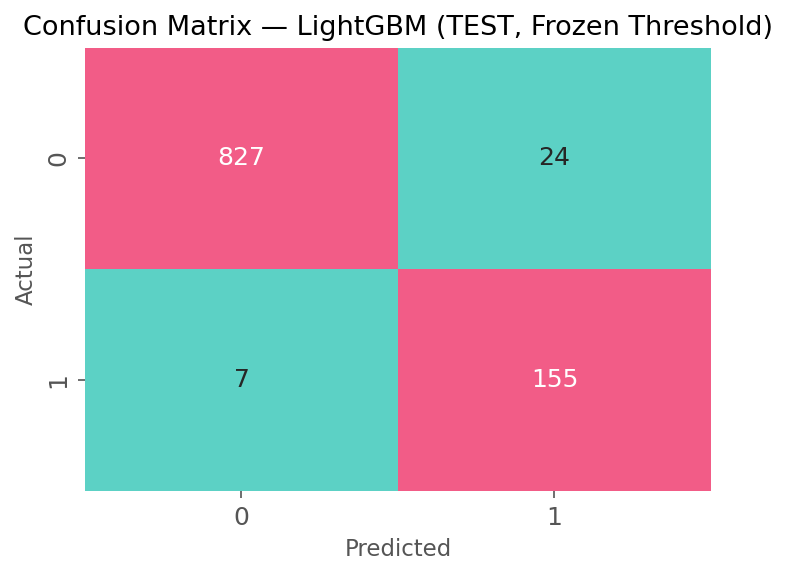


===== EXECUTIVE SUMMARY — LIGHTGBM (TEST) =====


,Value
Metric,
F2 Score (churn = 1) [TEST],0.9371
Recall (churn = 1) [TEST],0.9568
Precision (churn = 1) [TEST],0.8659
Balanced Accuracy [TEST],0.9643
ROC-AUC [TEST],0.9935
PR-AUC [TEST],0.9748
Frozen Threshold (from VAL),0.2723
scale_pos_weight (TRAIN+VAL),7.2068


In [ ]:
# LIGHTGBM — Final Model Fit (TRAIN + VAL) and Confirmation on TEST
# ============================================================
# Purpose:
#   - Retrain using TRAIN+VAL to maximize learning signal
#   - Keep hyperparameters and threshold frozen (no re-tuning)
#   - Re-evaluate on TEST to confirm stability

# Workflow:
#   1) Load frozen hyperparameters from the selected configuration
#   2) Recompute class imbalance ratio on TRAIN + VAL
#   3) Retrain the model using combined data
#   4) Evaluate on TEST using the fixed threshold
# ============================================================

# Safety check: requires build_lgbm_pipeline from the common infrastructure
required_globals = ["build_lgbm_pipeline"]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Common infra is not loaded. Missing: "
        + ", ".join(missing)
        + ". Run the COMMON INFRA cell first."
    )

RANDOM_STATE = 42
SCORING_NAME = "PR-AUC"
BETA_THRESHOLD = 2.0  # F2 emphasizes recall

# Frozen hyperparameters from the selected Optuna configuration
# ============================================================

spw_mult_best = 1.3802998654302598  # from best params
best_params_lgb_frozen = {
    "n_estimators": 2272,
    "learning_rate": 0.013202700260711138,
    "num_leaves": 104,
    "max_depth": 5,
    "min_child_samples": 22,
    "min_split_gain": 0.11140570440980045,
    "subsample": 0.8992819819075484,
    "subsample_freq": 3,
    "colsample_bytree": 0.6761596069968356,
    "reg_alpha": 6.055129310001375e-07,
    "reg_lambda": 9.326994358848609e-08,
}

# Recompute class imbalance on TRAIN+VAL for scale_pos_weight (keeps TEST isolated)
# ============================================================

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

neg = float((y_trainval == 0).sum())
pos = float((y_trainval == 1).sum())
if pos == 0:
    raise ValueError("No positive samples in y_trainval. Check your labels/split.")

scale_pos_weight_trainval = (neg / pos) * float(spw_mult_best)

print(f"[LGBM FINAL] TRAIN+VAL imbalance (neg/pos): {neg/pos:.3f}")
print(f"[LGBM FINAL] TRAIN+VAL scale_pos_weight (with spw_mult): {scale_pos_weight_trainval:.3f}")

# Build final pipeline (feature engineering + native categoricals)
# ============================================================

final_params_lgb = {
    "random_state": RANDOM_STATE,
    "objective": "binary",
    "boosting_type": "gbdt",
    "force_col_wise": True,
    "verbosity": -1,
    "scale_pos_weight": scale_pos_weight_trainval,
}
final_params_lgb.update(best_params_lgb_frozen)

model_lgb_final = LGBMClassifier(**final_params_lgb)

pipe_lgb_final = build_lgbm_pipeline(
    model_lgb_final,
    feature_set="full",
    strict_schema=True
)

pipe_lgb_final.fit(X_trainval, y_trainval)

# Frozen decision threshold from validation calibration
# ============================================================

best_t_lgb_frozen = 0.272323  # frozen threshold from VAL

# Confirmation evaluation on TEST (frozen threshold)
# ============================================================

proba_test_lgb = pipe_lgb_final.predict_proba(X_test)[:, 1]
preds_test_lgb = (proba_test_lgb >= best_t_lgb_frozen).astype(int)

results_lgb_test = {
    "Threshold": float(best_t_lgb_frozen),
    f"F{int(BETA_THRESHOLD)} (churn=1)": fbeta_score(y_test, preds_test_lgb, beta=BETA_THRESHOLD, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test, proba_test_lgb),
    "PR-AUC (TEST)": average_precision_score(y_test, proba_test_lgb),
    "Recall (churn=1)": recall_score(y_test, preds_test_lgb, pos_label=1),
    "Precision (churn=1)": precision_score(y_test, preds_test_lgb, pos_label=1),
    "Balanced Accuracy": balanced_accuracy_score(y_test, preds_test_lgb),
    "Confusion": confusion_matrix(y_test, preds_test_lgb),
    "Report": classification_report(y_test, preds_test_lgb, digits=4),
    "scale_pos_weight": float(scale_pos_weight_trainval),
}

# FINAL LIGHTGBM RESULTS (TEST, Frozen Threshold)
# ============================================================
print("\n===== FINAL LIGHTGBM RESULTS (TEST, Frozen Threshold, Trained on TRAIN+VAL) =====")
print(results_lgb_test["Report"])
print(f"PR-AUC (TEST): {results_lgb_test['PR-AUC (TEST)']:.4f}")
print(f"ROC-AUC (TEST): {results_lgb_test['ROC-AUC']:.4f}")
print(f"F{int(BETA_THRESHOLD)} (churn=1) (TEST): {results_lgb_test[f'F{int(BETA_THRESHOLD)} (churn=1)']:.4f}")
print(f"Recall (churn=1) (TEST): {results_lgb_test['Recall (churn=1)']:.4f}")
print(f"Precision (churn=1) (TEST): {results_lgb_test['Precision (churn=1)']:.4f}")
print(f"Frozen Threshold (from VAL): {results_lgb_test['Threshold']:.3f}")
print(f"scale_pos_weight (TRAIN+VAL): {results_lgb_test['scale_pos_weight']:.3f}")

# ---------- CONFUSION MATRIX (TEST) ----------
cm = results_lgb_test["Confusion"]

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.color_palette([color_palette[0], color_palette[1]], as_cmap=True) if "color_palette" in globals() else "Blues",
    norm=LogNorm(),
    cbar=False
)
plt.title("Confusion Matrix — LightGBM (TEST, Frozen Threshold)", fontsize=13)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.show()

# ---------- EXECUTIVE SUMMARY — MODEL PERFORMANCE (TEST) ----------
# Note: this section reports only holdout metrics (TEST) at the frozen operating point.

executive_summary_lgb_test = pd.DataFrame({
    "Metric": [
        f"F{int(BETA_THRESHOLD)} Score (churn = 1) [TEST]",
        "Recall (churn = 1) [TEST]",
        "Precision (churn = 1) [TEST]",
        "Balanced Accuracy [TEST]",
        "ROC-AUC [TEST]",
        "PR-AUC [TEST]",
        "Frozen Threshold (from VAL)",
        "scale_pos_weight (TRAIN+VAL)",
    ],
    "Value": [
        results_lgb_test[f"F{int(BETA_THRESHOLD)} (churn=1)"],
        results_lgb_test["Recall (churn=1)"],
        results_lgb_test["Precision (churn=1)"],
        results_lgb_test["Balanced Accuracy"],
        results_lgb_test["ROC-AUC"],
        results_lgb_test["PR-AUC (TEST)"],
        results_lgb_test["Threshold"],
        results_lgb_test["scale_pos_weight"],
    ]
}).set_index("Metric").round(4)

print("\n===== EXECUTIVE SUMMARY — LIGHTGBM (TEST) =====")
display(executive_summary_lgb_test)

## Final Model Performance — Test Set Evaluation

The final LightGBM model maintains strong and consistent performance after being retrained on the full development dataset, confirming that the learned patterns generalize well to unseen data.

The model achieves a PR-AUC of 0.9748 and a ROC-AUC of 0.9935, demonstrating excellent discriminative power and strong ranking capability under class imbalance.

From a business perspective, recall for the churn class reaches 95.68%, indicating that the model successfully identifies the vast majority of customers at risk of leaving. This aligns directly with the project objective of minimizing missed churn cases.

Precision remains solid at 86.59%, ensuring that the increase in churn detection does not excessively inflate false positives, thereby maintaining operational efficiency.

The F2 score of 0.9371 confirms that the model achieves a strong balance aligned with the defined objective of prioritizing recall while preserving reasonable precision.

Overall, these results indicate that retraining improved model robustness while preserving performance stability, reinforcing confidence in the model’s ability to support real-world churn risk assessment.

## Model Interpretability — Understanding Prediction Drivers

While predictive performance is essential, interpretability plays a critical role in ensuring that model outputs can be trusted and understood by stakeholders. In real-world business environments, decision-makers need to understand not only which customers are at risk but also why the model identifies them as such.

To address this requirement, SHAP (SHapley Additive exPlanations) analysis is applied to the final model. SHAP provides a theoretically grounded framework for quantifying the contribution of each feature to individual predictions, allowing both global and local interpretation of model behavior.

The analysis focuses on three complementary perspectives:

- Global feature importance to identify the main drivers of churn
- Feature dependence plots to understand nonlinear relationships
- Local explanations to illustrate how specific predictions are formed

Together, these analyses provide transparency into the model’s decision process and help validate that predictions are driven by meaningful behavioral patterns rather than spurious correlations.

[SHAP] Pipeline steps: ['prep', 'model']
[SHAP] Model: LGBMClassifier
[SHAP] Transformed TEST shape: (1013, 59)
[SHAP] Using sampled TEST rows: 800
[SHAP] SHAP values shape: (800, 59)

===== SHAP GLOBAL IMPORTANCE (TEST) — Top 11 (with extra columns) =====


,rank,feature,dtype,mean_abs_shap,impact_%,mean_shap_signed,"corr(value, shap)"
0,1,total_trans_amt,int64,1.145596,9.64,-0.071571,-0.233
1,2,net_activity_flow,int64,1.060105,8.93,0.025611,-0.047
2,3,total_trans_ct,int64,0.761294,6.41,0.003178,-0.063
3,4,total_revolving_bal,int64,0.726368,6.12,-0.049423,-0.211
4,5,inactivity_ratio,float64,0.603262,5.08,0.019114,-0.040
5,6,spending_momentum,float64,0.535035,4.50,-0.142851,0.127
6,7,trans_ct_per_contacts,float64,0.496136,4.18,0.011792,0.165
7,8,trans_amt_per_credit,float64,0.459242,3.87,0.037176,-0.001
8,9,total_amt_chng_q4_q1,float64,0.398034,3.35,-0.008695,-0.049
9,10,avg_product_value,float64,0.339001,2.85,0.079973,0.071


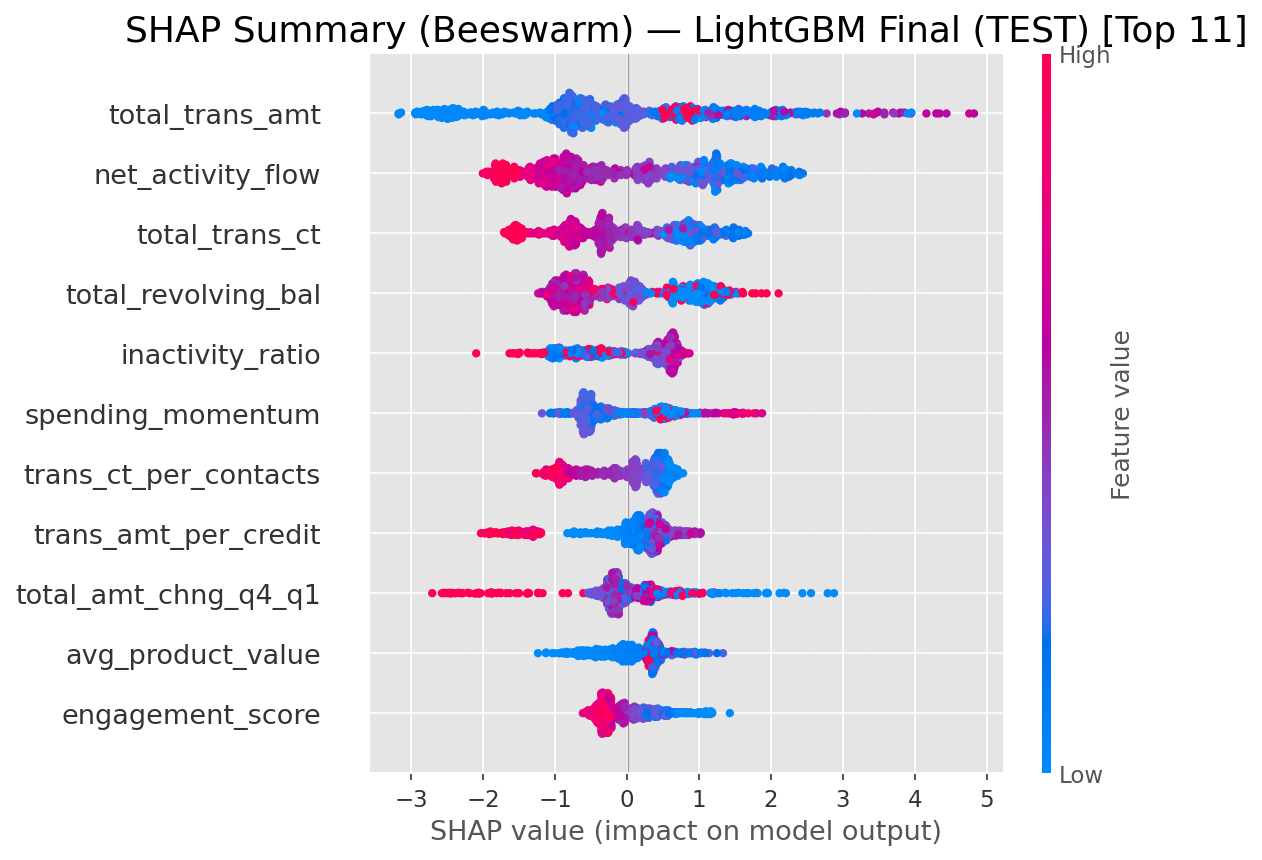

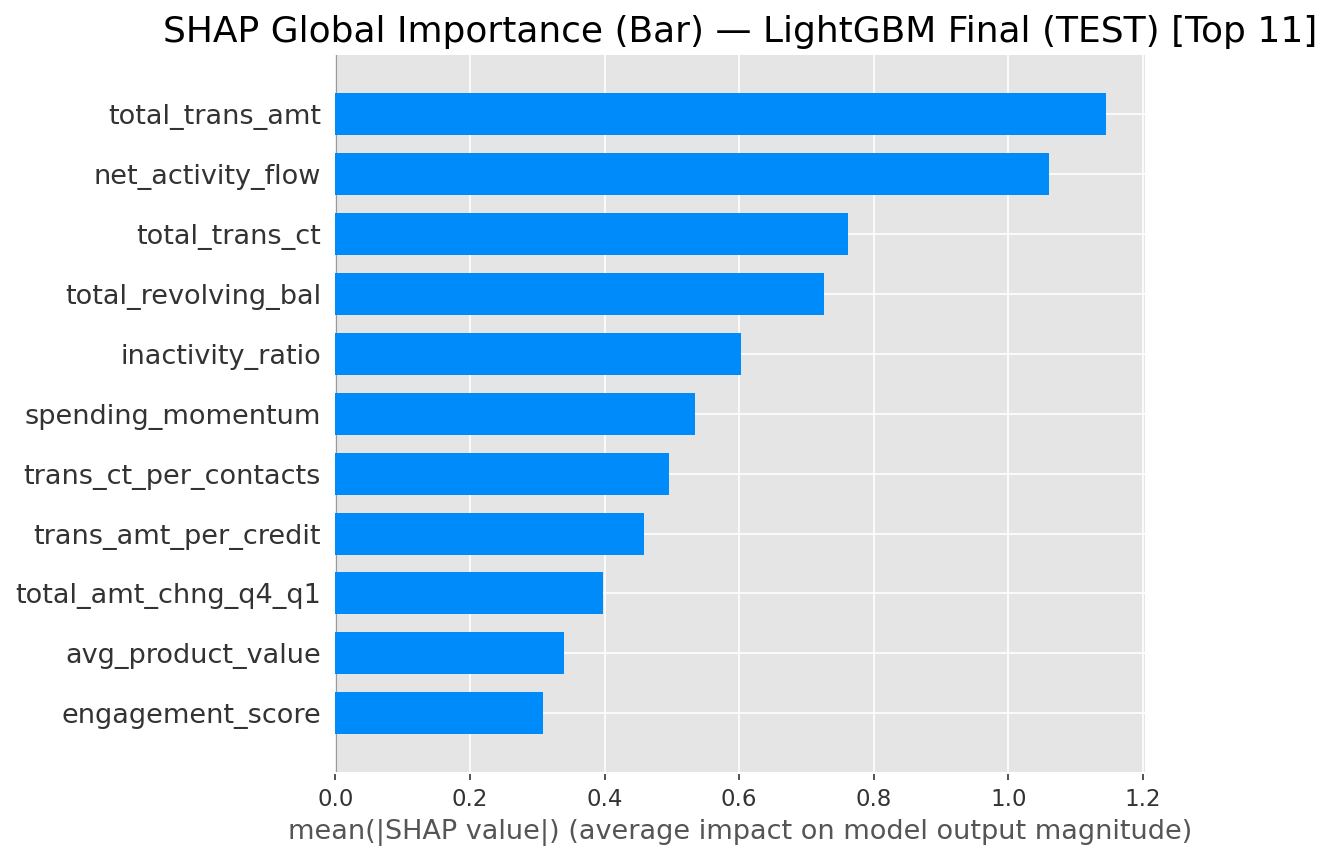


[SHAP] Dependence plots will be generated for 11 numeric top features.


<Figure size 1200x750 with 0 Axes>

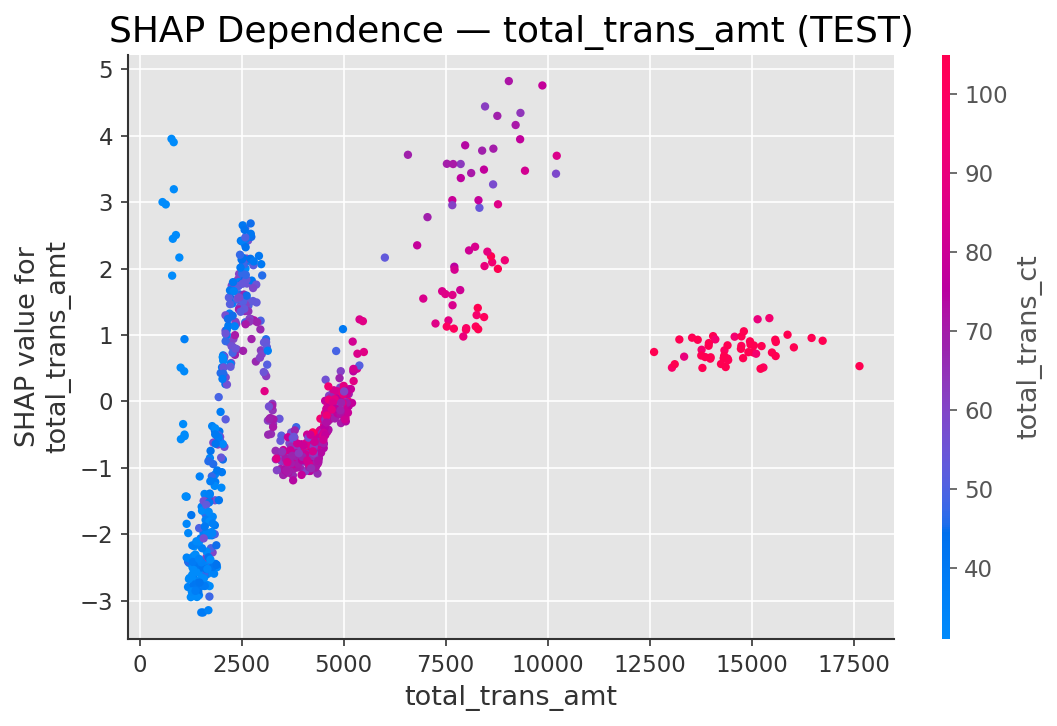

<Figure size 1200x750 with 0 Axes>

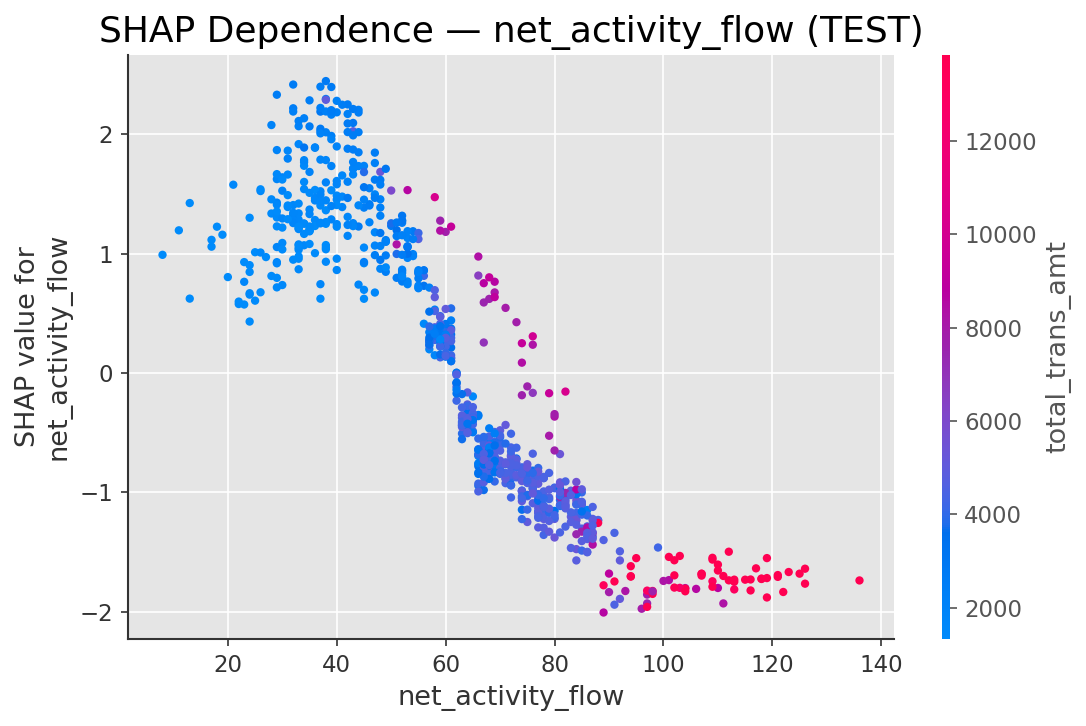

<Figure size 1200x750 with 0 Axes>

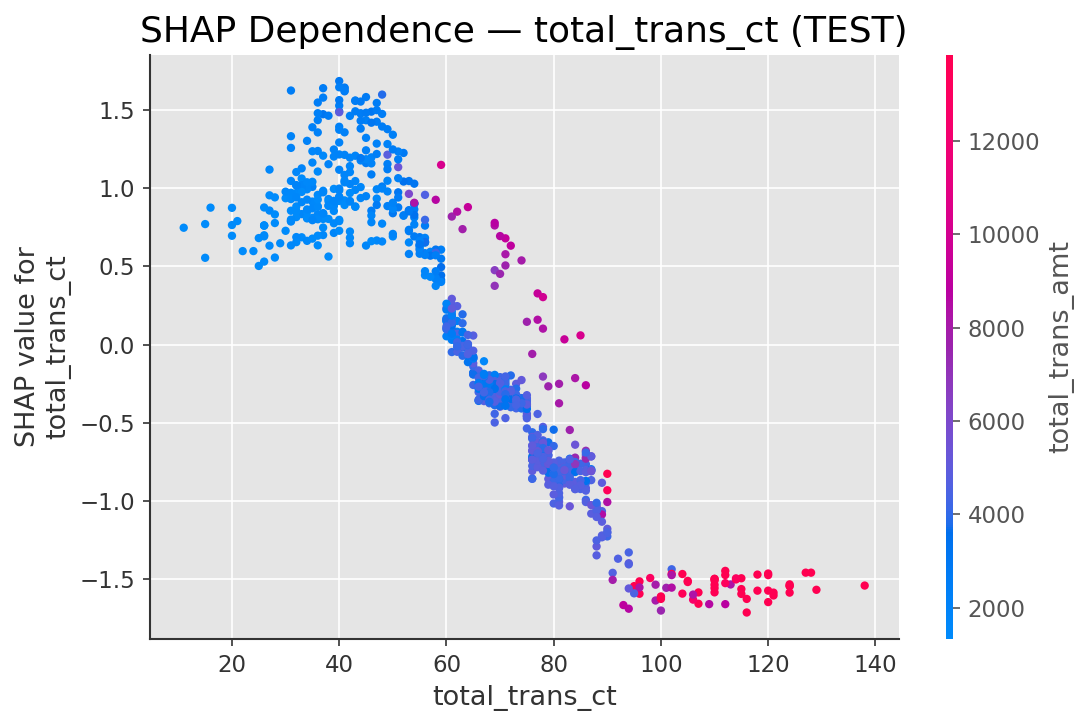

<Figure size 1200x750 with 0 Axes>

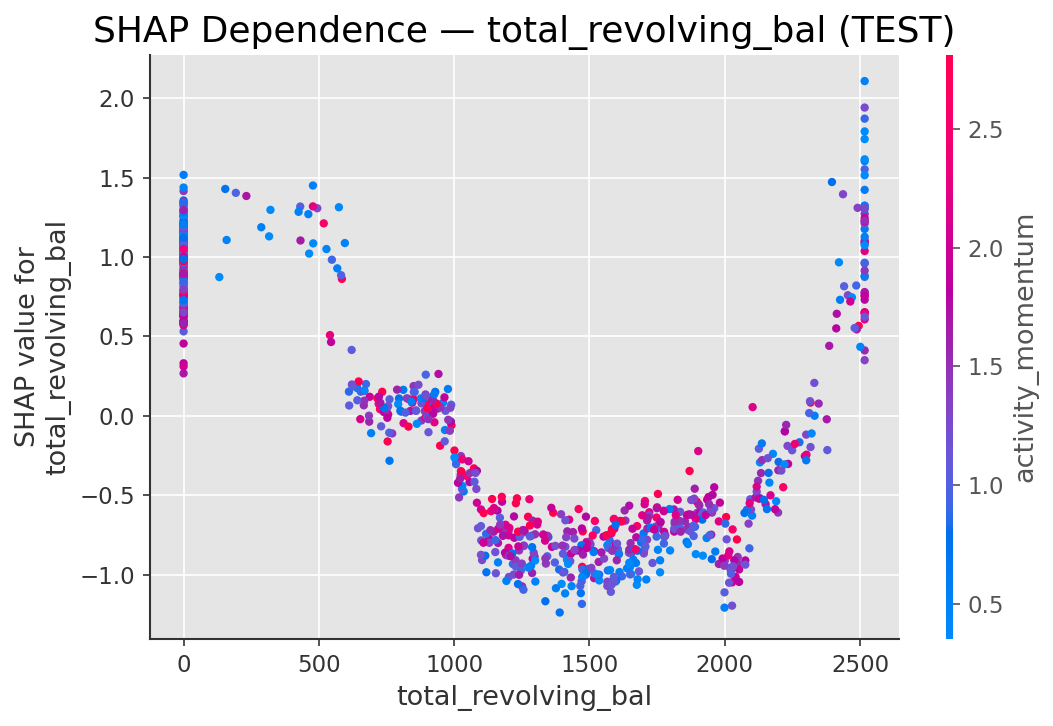

<Figure size 1200x750 with 0 Axes>

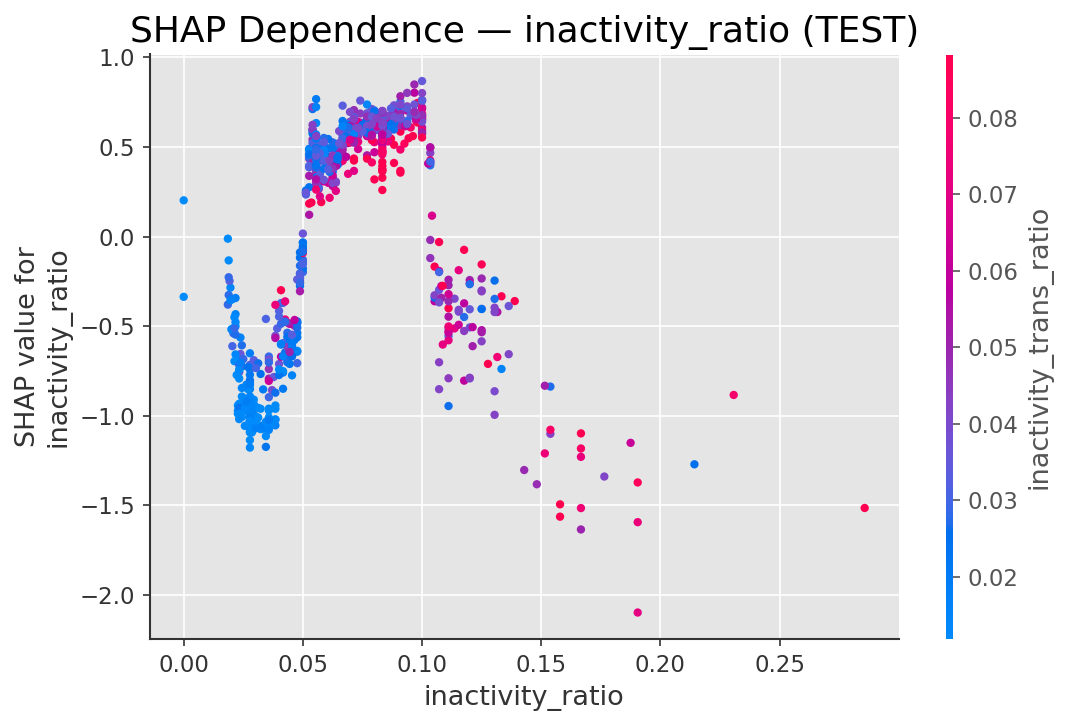

<Figure size 1200x750 with 0 Axes>

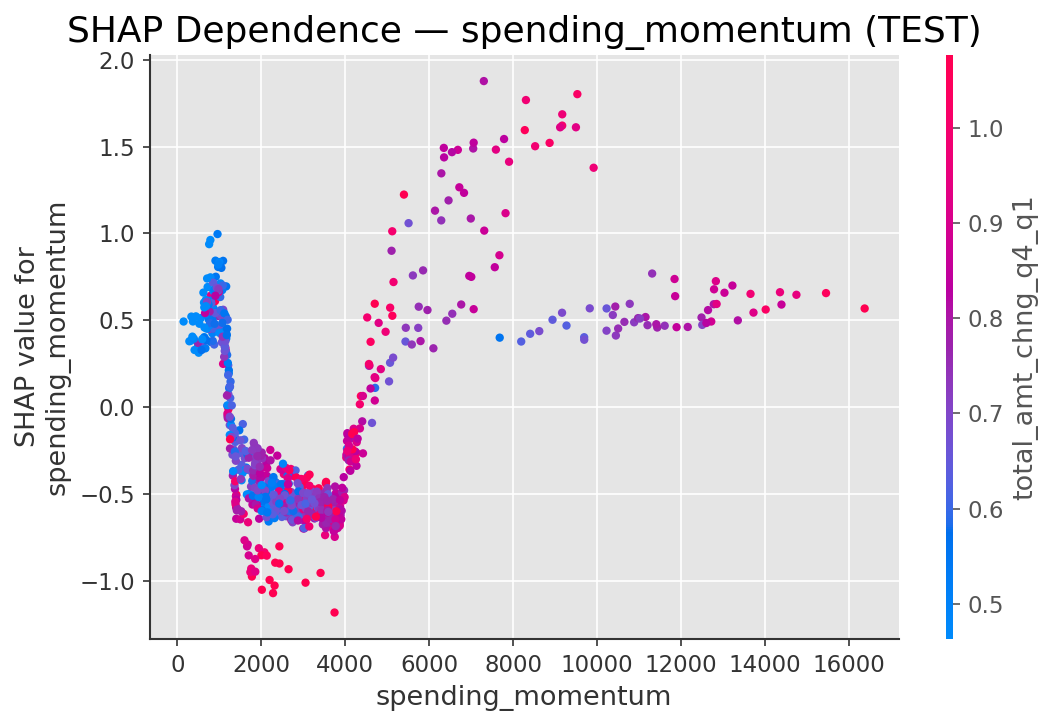

<Figure size 1200x750 with 0 Axes>

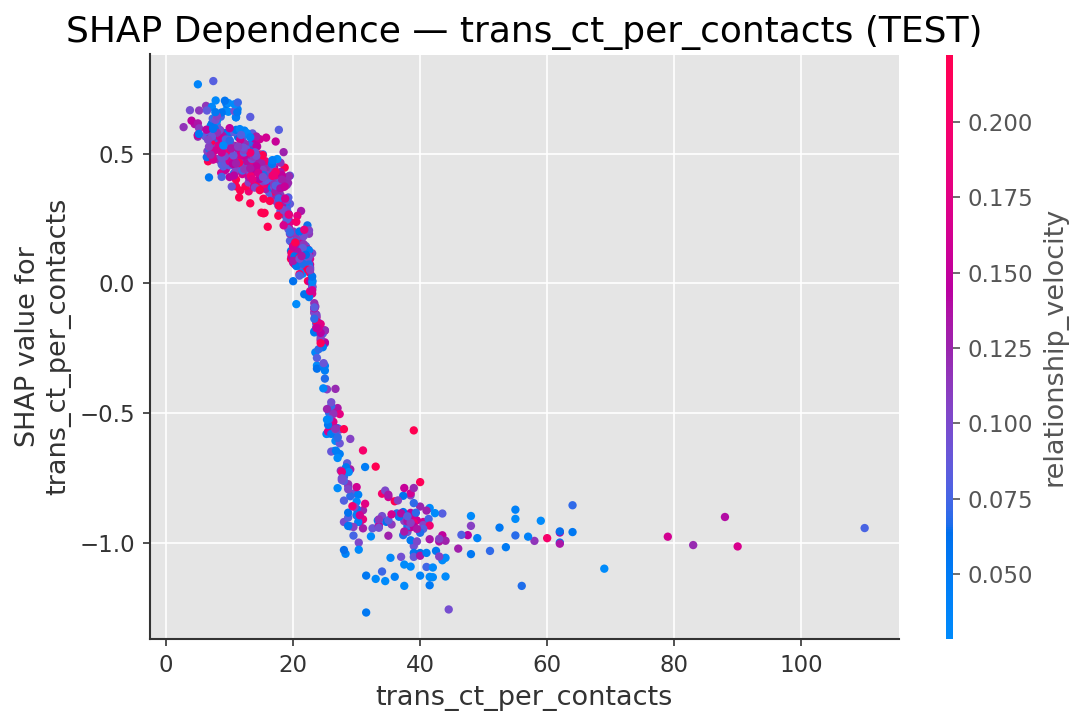

<Figure size 1200x750 with 0 Axes>

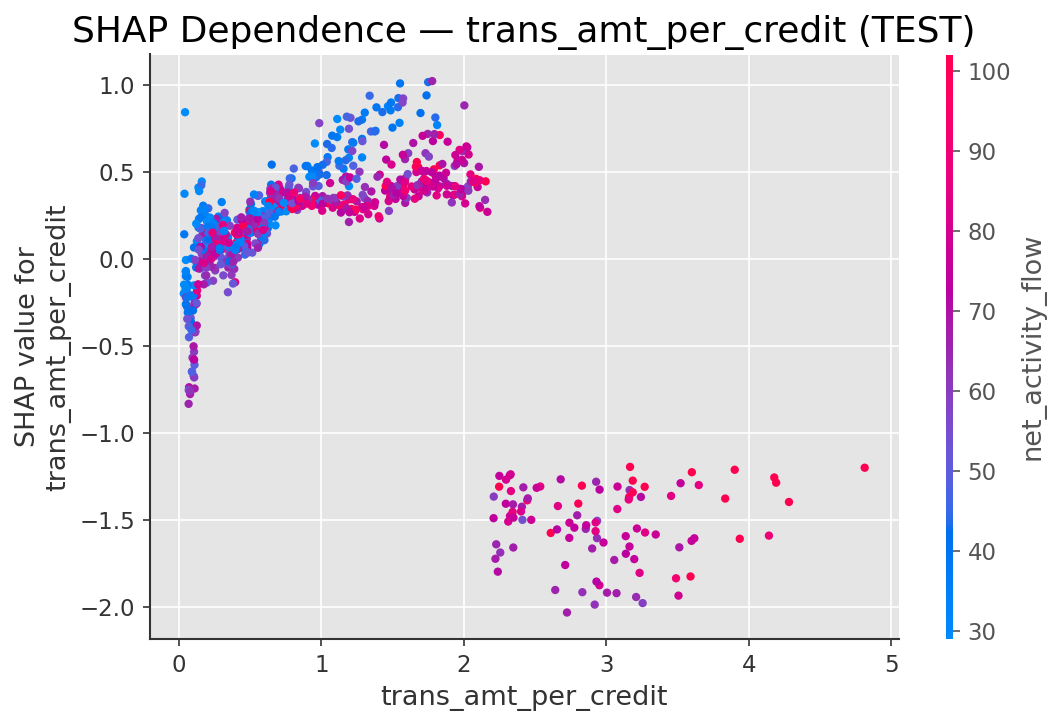

<Figure size 1200x750 with 0 Axes>

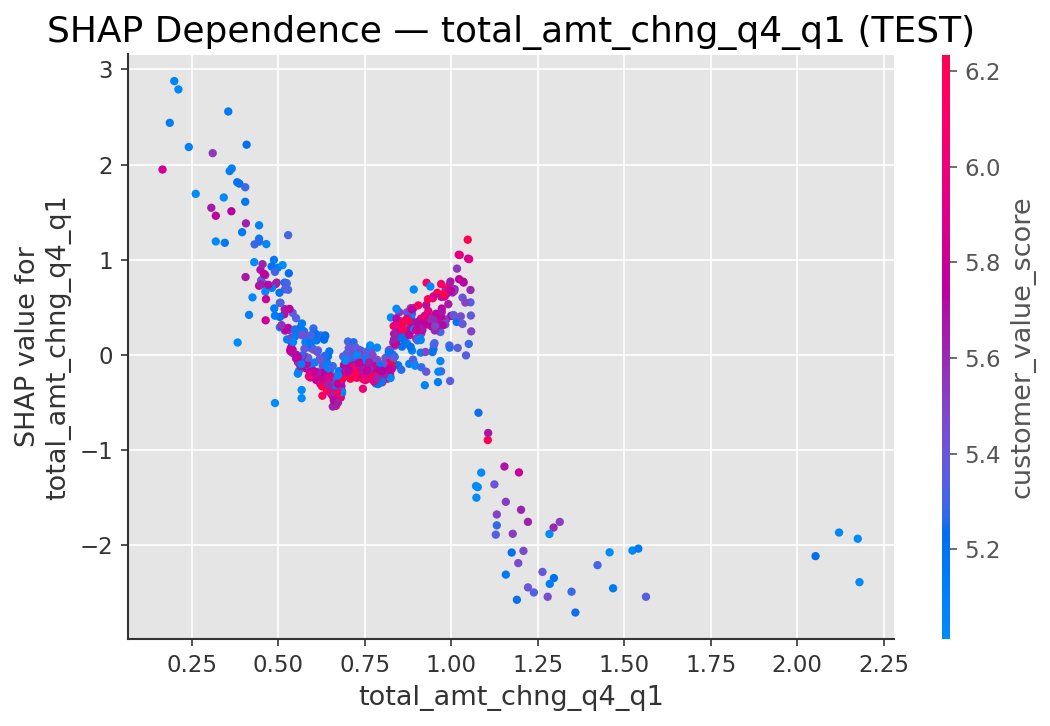

<Figure size 1200x750 with 0 Axes>

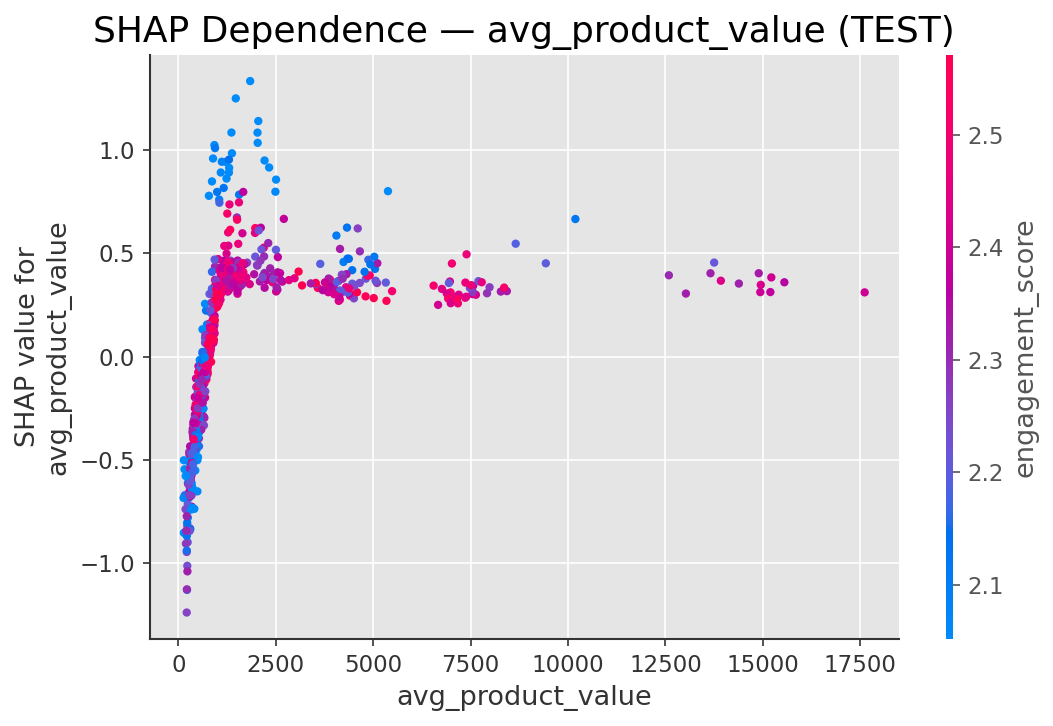

<Figure size 1200x750 with 0 Axes>

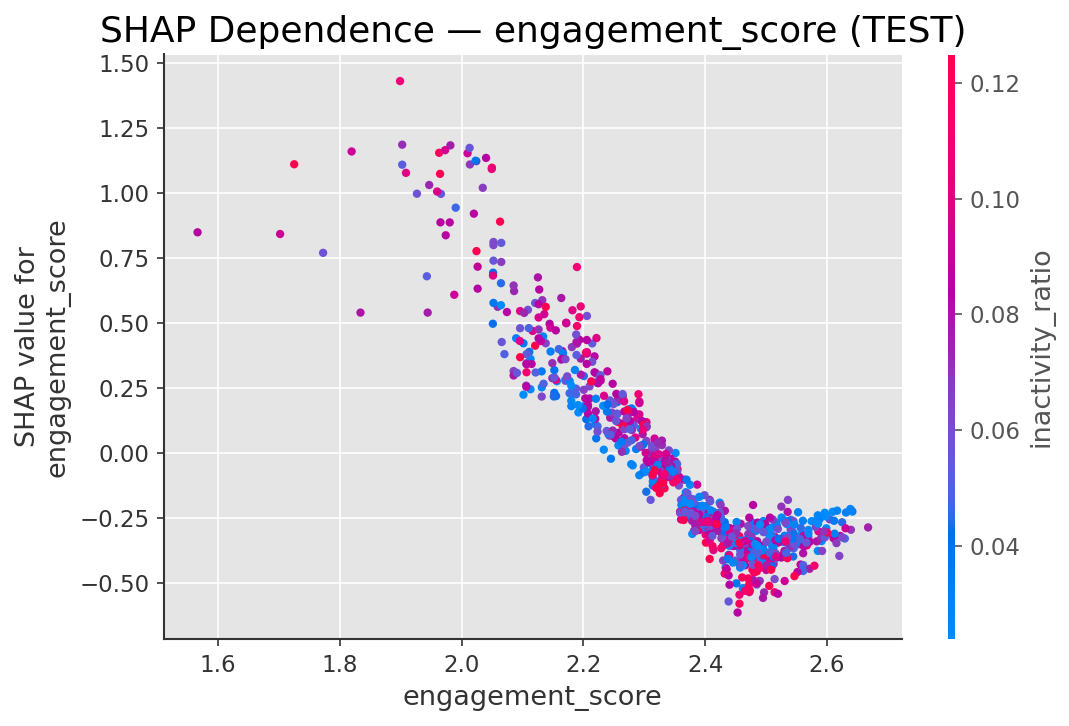


[SHAP] Waterfall: using a churn=1 example from SHAP subset.


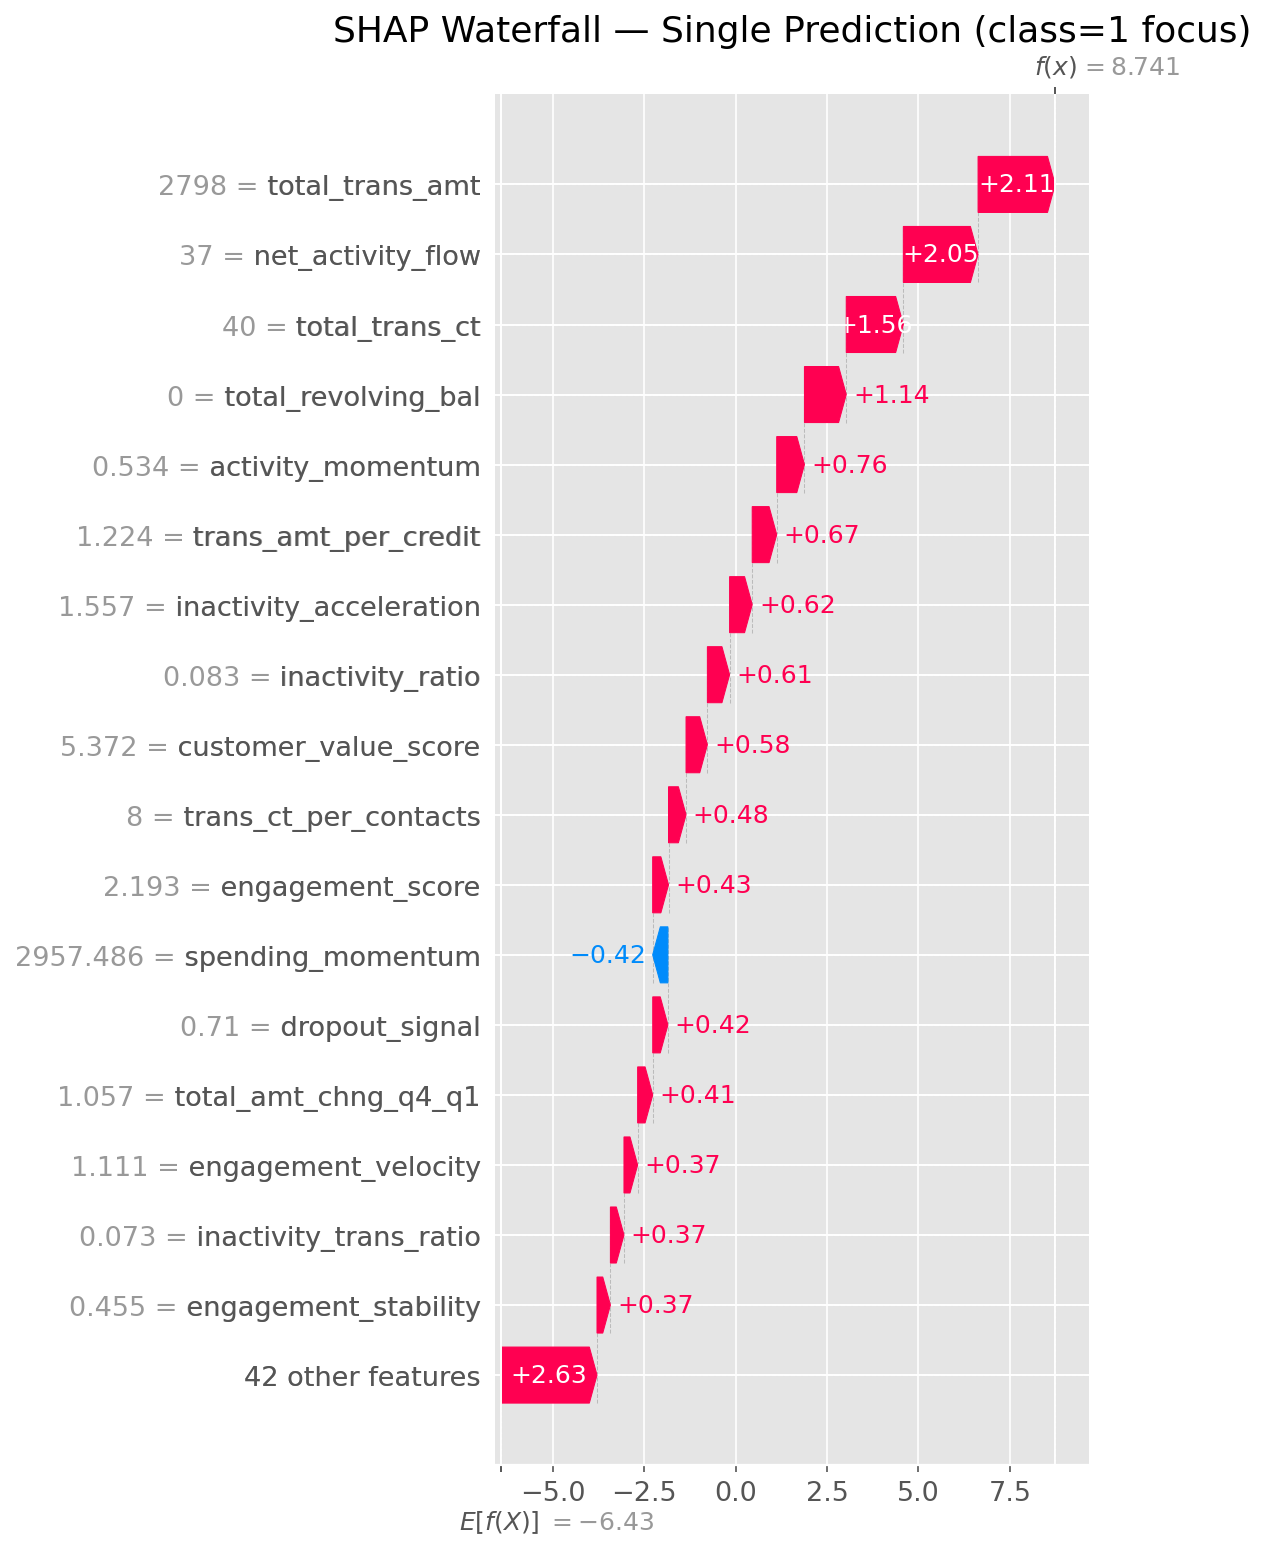

In [ ]:
# SHAP — LIGHTGBM (Final model trained on TRAIN+VAL) [SIMPLE: 1 plot per line]
# ============================================================
# Assumes:
#   - pipe_lgb_final : Pipeline([("prep", Preprocessor(...)), ("model", LGBMClassifier(...))])
#   - X_test, y_test available
# Outputs:
#   - Global importance table (TOP 11) + extra columns
#   - Beeswarm + Bar (TOP 11)
#   - Dependence plots (TOP numeric features only) — one per figure (no subplots)
#   - Waterfall for one churn=1 example (or highest-proba fallback)
# ============================================================

# -----------------------------
# 0) Point to your FINAL pipeline
# -----------------------------
pipeline = pipe_lgb_final
prep = pipeline.named_steps["prep"]
model = pipeline.named_steps["model"]

print("[SHAP] Pipeline steps:", list(pipeline.named_steps.keys()))
print("[SHAP] Model:", type(model).__name__)

# 1) Transform TEST like the model sees
# -----------------------------
X_test_trans = prep.transform(X_test)

if not isinstance(X_test_trans, pd.DataFrame):
    X_test_trans = pd.DataFrame(
        X_test_trans,
        columns=[f"f_{i}" for i in range(X_test_trans.shape[1])]
    )

feature_names = X_test_trans.columns.tolist()
print(f"[SHAP] Transformed TEST shape: {X_test_trans.shape}")

# Optional speed-up: sample rows for SHAP
MAX_SHAP_ROWS = 800
if len(X_test_trans) > MAX_SHAP_ROWS:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_test_trans), size=MAX_SHAP_ROWS, replace=False)
    X_shap = X_test_trans.iloc[idx].copy()
    y_shap = y_test.iloc[idx].copy()
    print(f"[SHAP] Using sampled TEST rows: {len(X_shap)}")
else:
    X_shap = X_test_trans.copy()
    y_shap = y_test.copy()

# -----------------------------
# 2) Build explainer (LightGBM TreeExplainer)
# -----------------------------
booster = getattr(model, "booster_", None)
explainer = shap.TreeExplainer(booster if booster is not None else model)

shap_values = explainer.shap_values(X_shap)

# Normalize binary output -> class 1
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

shap_values_class1 = np.asarray(shap_values_class1)
print(f"[SHAP] SHAP values shape: {shap_values_class1.shape}")

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and len(np.atleast_1d(expected_value)) == 2:
    expected_value = expected_value[1]

# -----------------------------
# 3) Global importance table (TOP 11) + extra columns
# -----------------------------
mean_abs = np.mean(np.abs(shap_values_class1), axis=0)
mean_signed = np.mean(shap_values_class1, axis=0)

feature_dtype = X_shap.dtypes.astype(str)

# Correlation between feature values and SHAP (numeric only)
corr = []
for j, f in enumerate(feature_names):
    s = pd.to_numeric(X_shap[f], errors="coerce")
    if s.notna().sum() >= 3:
        corr.append(float(pd.Series(shap_values_class1[:, j]).corr(s)))
    else:
        corr.append(np.nan)

total = float(np.sum(mean_abs)) if np.sum(mean_abs) != 0 else 1.0
pct = mean_abs / total * 100.0

shap_importance = (
    pd.DataFrame({
        "rank": np.arange(1, len(feature_names) + 1),
        "feature": feature_names,
        "dtype": feature_dtype.values,
        "mean_abs_shap": mean_abs,
        "impact_%": pct,
        "mean_shap_signed": mean_signed,
        "corr(value, shap)": corr,
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

topN = 11
top_imp = shap_importance.head(topN).copy()
top_imp["rank"] = np.arange(1, topN + 1)

print(f"\n===== SHAP GLOBAL IMPORTANCE (TEST) — Top {topN} (with extra columns) =====")
display(top_imp.style.format({
    "mean_abs_shap": "{:.6f}",
    "impact_%": "{:.2f}",
    "mean_shap_signed": "{:.6f}",
    "corr(value, shap)": "{:.3f}",
}))

# -----------------------------
# 4) Summary plots (TOP 11)
# -----------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class1,
    X_shap,
    feature_names=feature_names,
    max_display=topN,
    show=False
)
plt.title(f"SHAP Summary (Beeswarm) — LightGBM Final (TEST) [Top {topN}]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class1,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=topN,
    show=False
)
plt.title(f"SHAP Global Importance (Bar) — LightGBM Final (TEST) [Top {topN}]")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Dependence plots (TOP numeric features only) — one per figure
# -----------------------------
numeric_cols = X_shap.select_dtypes(include=[np.number]).columns.tolist()
top_numeric = [f for f in shap_importance["feature"].tolist() if f in numeric_cols][:topN]

if len(top_numeric) == 0:
    print("\n[SHAP] No numeric features found for dependence plots. Skipping.")
else:
    print(f"\n[SHAP] Dependence plots will be generated for {len(top_numeric)} numeric top features.")
    for f in top_numeric:
        plt.figure(figsize=(8, 5))
        try:
            shap.dependence_plot(
                f,
                shap_values_class1,
                X_shap,
                feature_names=feature_names,
                interaction_index="auto",
                show=False
            )
            plt.title(f"SHAP Dependence — {f} (TEST)")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            plt.clf()
            plt.figure(figsize=(8, 2.5))
            plt.axis("off")
            plt.text(0.01, 0.5, f"Skipped dependence plot for '{f}'\n{type(e).__name__}: {e}")
            plt.show()

# -----------------------------
# 6) Local explanation (waterfall) for one churn=1 example
# -----------------------------
pos_idx = np.where(np.asarray(y_shap) == 1)[0]

if len(pos_idx) > 0:
    i = int(pos_idx[0])
    x0 = X_shap.iloc[i]
    sv0 = shap_values_class1[i]
    print("\n[SHAP] Waterfall: using a churn=1 example from SHAP subset.")
else:
    proba_full = pipeline.predict_proba(X_test)[:, 1]
    idx_global = int(np.argmax(proba_full))
    x0 = X_test_trans.iloc[idx_global]

    x0_df = pd.DataFrame([x0.values], columns=feature_names)
    sv0 = explainer.shap_values(x0_df)
    sv0 = sv0[1] if isinstance(sv0, list) and len(sv0) == 2 else sv0
    sv0 = np.asarray(sv0).reshape(-1)

    print("\n[SHAP] Waterfall: no churn=1 in subset; using highest predicted-prob TEST row.")

exp = shap.Explanation(
    values=sv0,
    base_values=expected_value,
    data=x0.values,
    feature_names=feature_names,
)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(exp, max_display=18, show=False)
plt.title("SHAP Waterfall — Single Prediction (class=1 focus)")
plt.tight_layout()
plt.show()

## SHAP Analysis — Behavioral Insights and Model Transparency

The SHAP analysis reveals clear and intuitive patterns consistent with expected customer behavior in a credit card context. Transaction activity and engagement-related features dominate the importance rankings, indicating that the model primarily relies on meaningful behavioral signals.

Total transaction amount emerges as the most influential feature, highlighting the role of spending intensity as a key indicator of customer engagement. Sustained transaction activity is associated with lower churn risk, while declining activity increases attrition probability.

Net activity flow and transaction count reinforce this pattern, showing that both the magnitude and frequency of financial interactions are strong predictors of retention. Balance-related variables, such as total revolving balance, further reflect how credit utilization behavior contributes to churn dynamics.

Dependence plots reveal nonlinear relationships across several features, confirming that churn risk is influenced by complex behavioral shifts rather than simple linear effects. Local explanations also show that individual predictions are driven by coherent combinations of engagement and activity signals, reinforcing confidence in the model’s reasoning process.

Overall, the interpretability analysis confirms that the model captures meaningful behavioral dynamics while maintaining transparency and explainability.

## Final Conclusion — Business Impact and Model Positioning

This project aimed to develop a machine learning solution capable of identifying customers at risk of churn in a credit card portfolio, with the primary objective of maximizing churn detection while maintaining operational control over false positives.

The final LightGBM model demonstrates strong predictive performance, robust generalization, and high interpretability. By optimizing the decision threshold using an F2-oriented strategy, the model prioritizes recall while maintaining solid precision, ensuring alignment with real-world retention objectives.

From a positioning standpoint, the solution is best interpreted as a **risk scoring model**, providing probabilistic churn estimates that enable prioritization strategies and targeted intervention rather than acting solely as a binary classifier.

The final evaluation confirms the model’s effectiveness:

* High recall ensures most churners are detected
* Strong PR-AUC reflects excellent performance under class imbalance
* High ROC-AUC confirms strong ranking capability
* Stable precision indicates manageable operational impact

These characteristics make the model well suited for practical churn risk assessment scenarios.

---

# 💰 Estimated Business Impact: Conservative Retention Scenario

To estimate financial impact conservatively, we assume:

- Only **15% of identified churners** are successfully retained  
- Customer value is estimated based on realistic revenue drivers in a credit card portfolio  
- No additional revenue from cross-sell, engagement uplift, or cost reduction is considered  

---

## 📊 Customer Value Estimation

Given the dataset represents a credit card portfolio, customer value was estimated considering two primary revenue streams:

### 1. Transaction-based revenue (interchange)
- Average annual transaction volume: **~4,400 monetary units**
- Assumed interchange rate: **~2%**
- Estimated annual revenue: **~88**

### 2. Interest on revolving balances
- Average revolving balance (proxy): **~1,500 monetary units**
- Assumed annual interest rate: **~25%**
- Estimated annual revenue: **~375**

###  Total estimated annual revenue per customer: > **~460 monetary units**
###  Observed churn rate: > **~16%**

---

### 📊 Estimated Customer Lifetime Value (LTV):
LTV ≈ Annual Revenue / Churn Rate
> **~2,800 monetary units per customer**

---

### Retention Impact

**Identified churners:**
1,551 customers  

**Successfully retained (15%):**
1,551 × 15% ≈ **233 customers**

## 💰 Estimated Retained Value

233 × 2,800 ≈ **~650,000 monetary units**

---

### ⚠️ Conservative Assumptions

This estimate intentionally:

- Uses simplified assumptions for interchange and interest rates  
- Approximates customer value without full revenue decomposition  
- Excludes cross-sell, upsell, and behavioral uplift  
- Does not account for operational cost reductions  

Therefore, this should be interpreted as a **conservative and lower-bound estimate** of financial impact.

---

## 🚀 Strategic Implications

Given:

- ~10,127 customers  
- Churn rate ≈ 16%  

And a model recall above **95%**, the solution is capable of identifying the majority of at-risk customers.

Even under conservative assumptions, the model enables:

- **Hundreds of thousands in preserved value**
- Risk-based customer prioritization  
- More efficient allocation of retention resources  
- Integration with CRM-driven retention workflows  

Beyond direct financial impact, this approach strengthens decision-making by aligning predictive modeling with real business value drivers.

---

## Final Assessment

Overall, this project demonstrates how machine learning can transform behavioral customer data into actionable insights with measurable business value.

The final model delivers a strong combination of predictive performance, interpretability, and operational relevance, enabling proactive churn prevention strategies and supporting data-driven decision-making.

Even under conservative assumptions, the model shows the potential to preserve **hundreds of thousands in customer lifetime value**, demonstrating that the solution is not only statistically robust but also economically meaningful and applicable in real-world scenarios.

The project presents a complete end-to-end workflow — from data preparation and model development to evaluation, interpretability, and business impact estimation — following best practices in applied data science and positioning the solution as ready for real-world implementation.

In [ ]:
# ---------- SAVE ALL ARTIFACTS — PRODUCTION READY ----------
# ---------- SANITY CHECKS ----------
required_globals = [
    "X", "y",
    "X_trainval", "y_trainval",
    "X_test", "y_test",
    "pipe_lgb_final",
    "best_t_lgb_frozen",
    "results_lgb_test",
    "proba_test_lgb",
    "best_params_lgb_frozen",
    "spw_mult_best",
    "scale_pos_weight_trainval",
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables to save artifacts: "
        + ", ".join(missing)
        + ". Make sure you executed the final training cell."
    )

# ---------- CREATE ARTIFACTS DIRECTORY ----------
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------- SAVE FINAL DATASET (PRE-SPLIT) ----------
final_dataset = pd.concat([X, y.rename("churn_flag")], axis=1)
joblib.dump(final_dataset, ARTIFACTS_DIR / "final_dataset.pkl")

# ---------- SAVE FEATURE LIST (RAW, PRE-PREPROCESSOR) ----------
feature_list = list(X.columns)
joblib.dump(feature_list, ARTIFACTS_DIR / "feature_list.pkl")

# ---------- SAVE PREPROCESSING + MODEL PIPELINE (FINAL) ----------
joblib.dump(pipe_lgb_final, ARTIFACTS_DIR / "lgbm_pipeline.pkl")

# ---------- SAVE DECISION THRESHOLD (FROZEN FROM VAL) ----------
THRESHOLD = float(best_t_lgb_frozen)
joblib.dump(THRESHOLD, ARTIFACTS_DIR / "decision_threshold.pkl")

# ---------- SAVE FINAL EVALUATION METRICS (TEST) ----------
# Uses your standardized dict keys from results_lgb_test
final_metrics = {
    "f2_churn1": float(results_lgb_test.get("F2 (churn=1)", np.nan)),
    "recall_churn1": float(results_lgb_test.get("Recall (churn=1)", np.nan)),
    "precision_churn1": float(results_lgb_test.get("Precision (churn=1)", np.nan)),
    "roc_auc": float(results_lgb_test.get("ROC-AUC", np.nan)),
    "pr_auc_test": float(results_lgb_test.get("PR-AUC (TEST)", np.nan)),
    "balanced_accuracy": float(results_lgb_test.get("Balanced Accuracy", np.nan)),
    "confusion_matrix": results_lgb_test["Confusion"].tolist(),
}
joblib.dump(final_metrics, ARTIFACTS_DIR / "final_metrics.pkl")

# ---------- SAVE PROBABILITY OUTPUTS (TEST SET) ----------
joblib.dump(
    {
        "y_test": y_test.values,
        "proba_test": np.asarray(proba_test_lgb),
        "threshold": THRESHOLD,
    },
    ARTIFACTS_DIR / "probability_outputs.pkl"
)

# ---------- SAVE FEATURE NAMES AFTER PREPROCESSING (FOR SHAP) ----------
# Your pipeline is Pipeline([("prep", Preprocessor(...)), ("model", LGBMClassifier(...))])
prep = pipe_lgb_final.named_steps["prep"]
X_test_trans = prep.transform(X_test)

if isinstance(X_test_trans, pd.DataFrame):
    feature_names_post = list(X_test_trans.columns)
else:
    feature_names_post = [f"f_{i}" for i in range(X_test_trans.shape[1])]

joblib.dump(feature_names_post, ARTIFACTS_DIR / "feature_names_post_transform.pkl")

# ---------- SAVE GENERAL MODEL CONFIGURATION ----------
neg = int((y_trainval == 0).sum())
pos = int((y_trainval == 1).sum())

config = {
    "model": "LightGBM",
    "objective": "Churn Prediction",
    "threshold_frozen_from_val": THRESHOLD,
    "hyperparameters": {
        **best_params_lgb_frozen,
        "spw_mult": float(spw_mult_best),
        "scale_pos_weight_trainval": float(scale_pos_weight_trainval),
    },
    "class_balance": {
        "positive_class": pos,
        "negative_class": neg,
        "neg_pos_ratio": float(neg / pos) if pos > 0 else None,
    },
    "dataset": {
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "churn_rate": float(y.mean()),
    },
    "test_metrics": final_metrics,
}
joblib.dump(config, ARTIFACTS_DIR / "model_config.pkl")

print("✅ All production artifacts saved successfully!")
print(f"📁 Saved in: {ARTIFACTS_DIR.resolve()}")


✅ All production artifacts saved successfully!
📁 Saved in: /home/leandro/DataScience/Portfolio/Churn-Prediction-Credit-Card/notebooks/artifacts
